<a href="https://colab.research.google.com/github/lucasnye/SC3021-Project/blob/main/SC3021_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import time
import datetime
from datetime import timedelta
from googleapiclient.discovery import build
import json
import sqlite3
%pip install requests
import requests
import numpy as np
%pip install scipy
from scipy import stats
%pip install scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
import warnings

# Wikidata
%pip install sparqlwrapper
from SPARQLWrapper import SPARQLWrapper, JSON

# Google Trends
%pip install pytrends
%pip -q install billboard.py pandas
from pytrends.request import TrendReq

# Billboard
# import billboard

# SQLite connection for this stage
conn = sqlite3.connect('legacy_effect.sqlite')

# Wikidata SPARQL setup
sparql = SPARQLWrapper("http://query.wikidata.org/sparql")
sparql.addCustomHttpHeader("User-Agent", "SC3021 Student Project/1.0")

print("Setup complete.")

Setup complete.


# **The Legacy Effect - Posthumous Music Consumption Analysis** 🎶🎸⚡



> How does an artist's death impact their popularity, and how long does posthumous popularity last?



# Hypothesis/Analysis Goal (Ask)

When prominent music artists pass away, their work often experiences renewed attention from fans, media coverage, and streaming platforms. However, the magnitude and duration of this "legacy effect" varies significantly across artists. In this project, we want to investigate patterns in posthumous music consumption and predict the extent of this effect based on pre-death characteristics and circumstances. Such predictive analysis could potentially support music estates in strategic catalog management, inform streaming platform recommendation algorithms, and provide insights into cultural memory and fan behavior.

# Data Source Identification and Exploration (Prepare)

**Requirement Analysis**\
To tackle the problem, we need data about music artists who have passed away, including when they died and relevant biographical information (genre, age at death). This data needs to be aligned with historical data quantifying the artist's popularity (Spotify streams, YouTube views, search trends etc.) that covers both pre-death and post-death periods. For accurate analysis, it is desirable to have sufficient data on artists across different genres, markets and time periods to enable meaningful pattern identification. We require time-series data at daily or weekly granularity to capture the temporal dynamics of posthumous popularity changes. Additionally, supplementary data on external events (media coverage intensity, tribute concerts, documentary releases) would enhance our ability to explain variance in posthumous popularity patterns.
<br></br>

**List of Considered Sources**
In the following, we outline several sources we considered and explored and justify the final source selection (marked with an *), in particular based on concepts discussed in class.

*  DS1: [Spotify Web API](https://developer.spotify.com/documentation/web-api)
*  DS2*: [Google Trends API](https://developers.google.com/search/blog/2025/07/trends-api)
*  DS3: [Youtube Data API](https://developers.google.com/youtube/v3)
*  DS4*: [Wikidata](https://www.wikidata.org/wiki/Wikidata:REST_API)
*  DS5: [MusicBrainz Database](https://musicbrainz.org/doc/MusicBrainz_Database)
*  DS6*: [Billboard Charts API](https://github.com/guoguo12/billboard-charts)

# DS1: Spotify Web API

We instinctively gravitated towards the Spotify Web API for music and streaming data given its popularity in the streaming market.

However, we realised that it is unfortunately down for improvement works, so we had to improvise. This led us to finding alternative datasets as discussed below.

# DS2: Google Trends API

Description: The Google Trends API provides consistently-scaled search interest data over time, all the way from 2004. Data granularity includes daily, weekly, monthly, and yearly aggregations, as well as region and sub-region.

In [3]:
pytrends = TrendReq(hl='en-US', tz=360)

mj = ["Michael Jackson"]
pytrends.build_payload(mj, timeframe='2009-05-01 2010-01-01', geo='')

mj_df = pytrends.interest_over_time()
print(mj_df)

wh = ["Whitney Houston"]
pytrends.build_payload(wh, timeframe='2012-01-01 2012-08-01')
wh_df = pytrends.interest_over_time()

print(wh_df)

            Michael Jackson  isPartial
date                                  
2009-05-01                0      False
2009-05-02                0      False
2009-05-03                0      False
2009-05-04                0      False
2009-05-05                0      False
...                     ...        ...
2009-12-28                2      False
2009-12-29                2      False
2009-12-30                2      False
2009-12-31                2      False
2010-01-01                2      False

[246 rows x 2 columns]
            Whitney Houston  isPartial
date                                  
2012-01-01                0      False
2012-01-02                0      False
2012-01-03                0      False
2012-01-04                0      False
2012-01-05                0      False
...                     ...        ...
2012-07-28                0      False
2012-07-29                0      False
2012-07-30                0      False
2012-07-31                0      False
2

Advantages
*   Daily granularity can give us specific insight to how an artist's popularity changes day-on-day.
*   Trends reflect actual user behavior (what people are searching for) rather than stated preferences often found in surveys.
*   With data going back to 2004, it is ideal for analysing both long-term legacy shifts for artists who passed decades ago and those who experienced recent "grief spikes".
*   The `isPartial` flag is a boolean indicator that tells you whether the data for a specific time period is "finalised" (False) or still "in progress" (True). We can use this to filter out partial data (`isPartial`==True)



Limitations
*   Data is normalised on a 0-100 scale. A value of "100" doesn't mean a fixed number of searches; it represents the peak interest for that specific time and location selection.
*   A spike in Google searches for an artist after their death doesn't always equal "popularity".







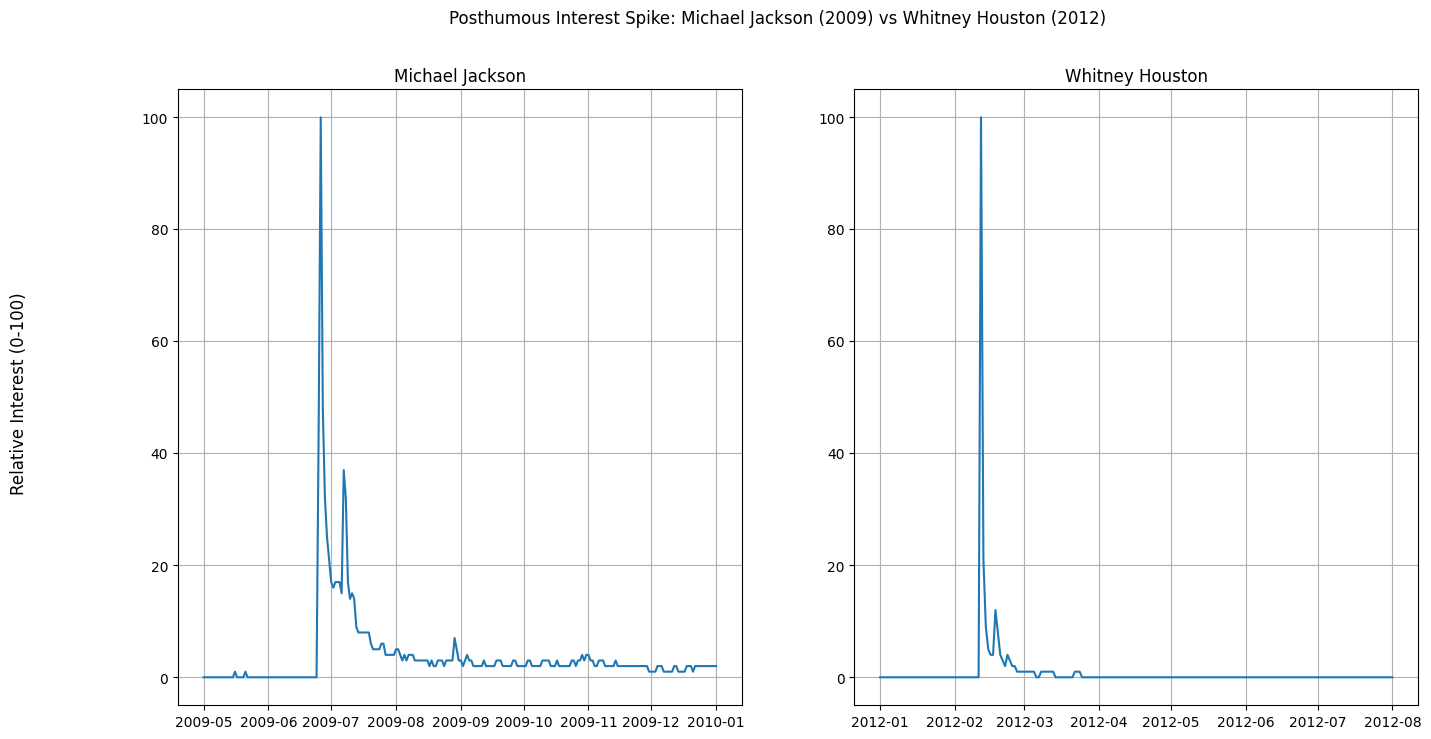

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Posthumous Interest Spike: Michael Jackson (2009) vs Whitney Houston (2012)")
fig.supylabel("Relative Interest (0-100)")

ax1.plot(mj_df.index, mj_df["Michael Jackson"])
ax1.set_title("Michael Jackson")
ax1.grid(True)

ax2.plot(wh_df.index, wh_df["Whitney Houston"], label="Search Interest")
ax2.grid(True)
ax2.set_title("Whitney Houston")

plt.show()

Looking at this sample data, we see that the date is stored in yyyy-mm-dd format, which needs to be taken into account when combined with other datasets.

We also must be cognizant of representation bias - the data only represents users with internet access and who use Google. This may underrepresent artists popular in regions where Google is not dominant (e.g., China, Russia) or among older demographics with less search-heavy habits.

All in all, we consider the dataset suited for our analysis, keeping in mind the limitations identified above, namely, that the popularity is normalised, and that Google searches may not necessarily equate to "popularity".

# DS3: Youtube Data API

Description: The YouTube Data API v3 is a RESTful interface that allows developers to interact with YouTube’s massive database of videos, channels, and playlists. It is primarily designed to let you search for content and retrieve public metadata about how users are engaging with that content.

In [6]:
from google.colab import userdata
API_KEY=userdata.get('YOUTUBE_KEY')

In [14]:
youtube = build("youtube", "v3", developerKey=API_KEY)

request = youtube.videos().list(
    part=["statistics", "snippet"],
    id="3JWTaaS7LdU" # 'I Will Always Love You' - Whitney Houston
)

response = request.execute()
statistics = response["items"][0]["statistics"]

df_stats = pd.DataFrame([statistics]) # view count, like count, favourite count, comment count

display(df_stats)

,viewCount,likeCount,favoriteCount,commentCount
0,1888901847,10797301,0,389427


In [15]:
snippet = response["items"][0]["snippet"]
df_snippet = pd.json_normalize(snippet, sep='.', max_level=1) # channelId, title, description, etc.
display(df_snippet)

,publishedAt,channelId,title,description,channelTitle,tags,categoryId,liveBroadcastContent,defaultLanguage,defaultAudioLanguage,thumbnails.default,thumbnails.medium,thumbnails.high,thumbnails.standard,thumbnails.maxres,localized.title,localized.description
0,2010-09-28T00:18:42Z,UCG5fkJ8-2b2ZjWpVNpr7Dqg,Whitney Houston - I Will Always Love You (Offi...,Official 4K Video for ”I Will Always Love You”...,whitneyhoustonVEVO,"[whitney houston, will always love you, will a...",10,none,en,en-US,{'url': 'https://i.ytimg.com/vi/3JWTaaS7LdU/de...,{'url': 'https://i.ytimg.com/vi/3JWTaaS7LdU/mq...,{'url': 'https://i.ytimg.com/vi/3JWTaaS7LdU/hq...,{'url': 'https://i.ytimg.com/vi/3JWTaaS7LdU/sd...,{'url': 'https://i.ytimg.com/vi/3JWTaaS7LdU/ma...,Whitney Houston - I Will Always Love You (Offi...,Official 4K Video for ”I Will Always Love You”...


Limitations

*   The biggest limitation is that the API provides only current data, and does not provide historical or time-series data (e.g. view count at specific times in the past).
*   Although the API can provide us useful data like view count, like count, comment count etc., we are unable to use them to compare popularity before and after an artist's passing.
*   Since there is also no dedicated API for YouTube Music, the sole use of the Youtube Data API may not capture all artist-specific streaming metadata.


In concluson, this API may be more relevant for alternative use cases such as investigating real-time engagement.

Hence, we decided not to continue exploring the Youtube Data API.

#DS4: Wikidata

###Description
The Wikidata dataset is a free, collaborative knowledge base maintained by the Wikimedia Foundation. It provides structured data that powers Wikipedia and other Wikimedia projects. Unlike Wikipedia's text articles, Wikidata stores information in a machine-readable format with standardized properties and unique identifiers.

For this project, we query Wikidata for musicians who died between 1970-2024. The data includes:
- Artist name and unique Wikidata ID (Q-number)
- Birth and death dates (precise to the day)
- Musical genre(s)
- Country of citizenship
- Occupation type (musician, singer, composer, etc.)

This dataset matches our requirements by providing the temporal anchor (death dates) needed to analyze posthumous streaming effects, along with biographical attributes that allow for demographic and genre-based comparisons. The data is queried via SPARQL, a query language for linked data, allowing us to filter for specific criteria and retrieve only relevant records.

The following code connects to Wikidata's SPARQL endpoint and retrieves deceased musicians from recent years.

In [16]:
# defining our SPARQL query
# link to get all properties (wdt): https://www.wikidata.org/wiki/Wikidata:Database_reports/List_of_properties/all
# link to get all the entities (wd): https://www.wikidata.org/wiki/Wikidata:Database_reports/Popular_items

query = """
SELECT DISTINCT ?artist ?artistLabel ?birthDate ?deathDate ?genreLabel ?countryLabel ?occupationLabel
WHERE {
  ?artist wdt:P31 wd:Q5 .
  ?artist wdt:P106 ?occupation .
  VALUES ?occupation {
    wd:Q639669    # musician
    wd:Q177220    # singer
    wd:Q36834     # composer
    wd:Q488205    # singer-songwriter
  }

  ?artist wdt:P570 ?deathDate .
  FILTER(YEAR(?deathDate) >= 1970 && YEAR(?deathDate) <= 2024)
  OPTIONAL { ?artist wdt:P569 ?birthDate . }
  OPTIONAL { ?artist wdt:P136 ?genre . }
  OPTIONAL { ?artist wdt:P27 ?country . }
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 50
"""

In [17]:
# executing our query
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

In [18]:
# converting to dataframe

data_rows = []
for result in results['results']['bindings']:
    row = {
        'artist_id': result['artist']['value'].split('/')[-1],
        'artist_name': result.get('artistLabel', {}).get('value', 'Unknown'),
        'birth_date': result.get('birthDate', {}).get('value', None),
        'death_date': result.get('deathDate', {}).get('value', None),
        'genre': result.get('genreLabel', {}).get('value', 'Unknown'),
        'country': result.get('countryLabel', {}).get('value', 'Unknown'),
        'occupation': result.get('occupationLabel', {}).get('value', 'Unknown')
    }
    data_rows.append(row)

df_wd = pd.DataFrame(data_rows)
df_wd

,artist_id,artist_name,birth_date,death_date,genre,country,occupation
0,Q49734,Cass Elliot,1941-09-19T00:00:00Z,1974-07-29T00:00:00Z,pop rock,United States,composer
1,Q46132,Alvin Lee,1944-12-19T00:00:00Z,2013-03-06T00:00:00Z,rock music,United Kingdom,composer
2,Q49575,Dizzy Gillespie,1917-10-21T00:00:00Z,1993-01-06T00:00:00Z,Afro-Cuban jazz,United States,composer
3,Q53031,Gillo Pontecorvo,1919-11-19T00:00:00Z,2006-10-12T00:00:00Z,Unknown,Italy,composer
4,Q51510,Wolfgang Hildesheimer,1916-12-09T00:00:00Z,1991-08-21T00:00:00Z,radio drama,Switzerland,composer
5,Q53031,Gillo Pontecorvo,1919-11-19T00:00:00Z,2006-10-12T00:00:00Z,Unknown,Kingdom of Italy,composer
6,Q48987,Jonathan Demme,1944-02-22T00:00:00Z,2017-04-26T00:00:00Z,action film,United States,composer
7,Q49888,Solomon Burke,1940-03-21T00:00:00Z,2010-10-10T00:00:00Z,gospel music,United States,composer
8,Q50003,Alberto Sordi,1920-06-15T00:00:00Z,2003-02-24T00:00:00Z,Unknown,Italy,composer
9,Q46100,Eugen Suchoň,1908-09-25T00:00:00Z,1993-08-05T00:00:00Z,opera,Slovakia,composer


The initial inspection shows that the dataset successfully captures biographical information for deceased musicians. Each record includes an artist identifier, temporal data (birth and death dates), and contextual attributes (genre, country). However, we observe that some artists may appear multiple times due to having multiple genres or occupations tagged in Wikidata. This will need to be addressed during data preparation.

### Profiling: Temporal Coverage of Deaths

To understand the temporal distribution of deaths in our dataset, we examine how many musicians died each year.

In [19]:
df_wd['death_year'] = pd.to_datetime(df_wd['death_date']).dt.year
year_counts = df_wd['death_year'].value_counts().sort_index()
year_counts

,count
death_year,
1972,7
1974,3
1976,1
1983,2
1985,1
1986,3
1991,1
1993,3
1999,1


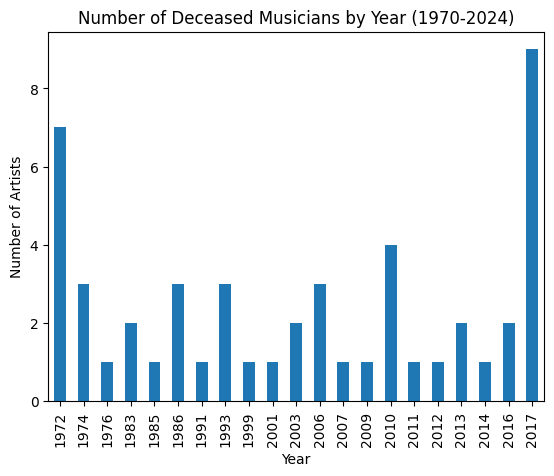

In [20]:
# visualize
year_counts.plot(
    kind='bar',
    title='Number of Deceased Musicians by Year (1970-2024)',
    xlabel='Year',
    ylabel='Number of Artists',
)
plt.show()

**Advantage** The distribution shows relatively consistent coverage across the 1970-2024 period, with some year-to-year variation. This temporal spread is important for our analysis, as it ensures we can examine posthumous streaming effects across different time periods and capture potential temporal trends in how fan behavior or streaming platform algorithms respond to artist deaths. The presence of recent deaths (e.g. 2023) is particularly valuable as it allows alignment with contemporary streaming data.

**Disclaimer** This graph only represents the 50 artists we have extracted (due to our limit) and thus, some years do not appear on the x-aix since years with 0 deaths aren't shown - even though there may be artists who have died in those years but did not appear in our list of 50.

### Profiling: Genre Diversity

Since posthumous consumption patterns may vary by musical genre, we examine the genre distribution in our dataset.

In [21]:
genre_counts = df_wd['genre'].value_counts().head(15)
genre_counts

,count
genre,
Unknown,11
opera,8
jazz,3
surrealism,2
rock music,2
radio drama,1
action film,1
gospel music,1
body horror film,1


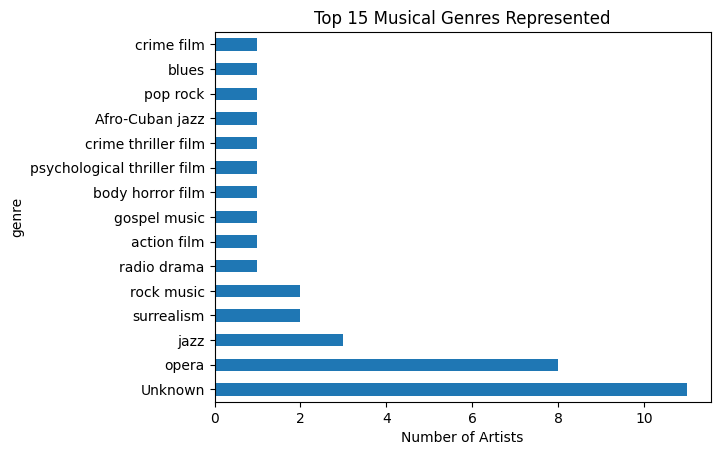

In [22]:
genre_counts.plot(
    kind='barh',
    title='Top 15 Musical Genres Represented',
    xlabel='Number of Artists',
)
plt.show()

**Advantage**
The genre distribution reveals representation across diverse musical styles, including rock, pop, jazz, classical, and regional music genres. This diversity is crucial for investigating whether posthumous streaming patterns differ across genres - for instance, whether classical musicians experience different legacy effects compared to pop artists.

**Disadvantage**
However, the presence of "Unknown" genres and the varying levels of granularity (e.g., "rock music" vs. "alternative rock") indicate that genre standardization will be necessary during data preparation to enable meaningful cross-genre comparisons.

###Data Quality Consideration

**Completeness**
The dataset shows high completeness for key fields required for this study. Artist names and death dates are available for all selected records, which are the most essential fields because the death date serves as the reference point for posthumous streaming analysis.

**Consistency**
All the records follow a consistent, structured format with standardized fields and unique Wikidata identifiers. However, because artists can have multiple genres and occupations, individual artists may appear multiple times in query results, leading to low per-genre counts. This is a structural characteristic of Wikidata but it can be resolved in the data cleaning processs.

**Granularity**
The dataset is recorded at the individual artist level, which is appropriate for aligning artist-specific death events with streaming, charts or trends time series. However, Wikidata does not include popularity metrics, streaming counts, etc. Therefore, it cannot be used independently to measure posthumous effects. Integration with other APIs is required.

**Temporal Alignment**
A key strength of this dataset is its overlap with the modern streaming era. This dataset allows us to extract information of artists that died during years when streaming platforms, charts or trends tracking measures were already established, allowing both pre-death and post-death consumption data to be analysed. Older historical datasets would not support this comparison, for example, this dataset which only records deaths of artists up to 2007: https://researchdatafinder.qut.edu.au/display/q1.


###Conclusion
Wikidata is a suitable biographical data source for this project. It provides reliable death dates, standardized artist identifiers, and open access without cost or licensing barriers. While limitations such as duplicate entries and incomplete genre annotations exist, these can be addressed through standard data cleaning and do not affect the dataset’s core role. Wikidata will therefore be used as a foundational metadata source, complemented by streaming platform data for consumption analysis.

#DS5: MusicBrainz Database

###Description

In [23]:
!pip install musicbrainzngs
import musicbrainzngs

In [24]:
# setting up a user agent (required by MusicBrainz)
musicbrainzngs.set_useragent(
    "SC3021-Posthumous-Music-Study",
    "1.0",
    "mahak001@e.ntu.edu.sg"
)

In [25]:
# query a small sample of artists with a recorded death date
result = musicbrainzngs.search_artists(
    query='type:person AND tag:singer AND life-span.end:[1970 TO 2025]',
    limit=50
)

# convert to a dataframe
artists = []
for a in result['artist-list']:
    life = a.get('life-span', {})
    artists.append({
        "name": a.get("name"),
        "type": a.get("type"),
        "country": a.get("country"),
        "birth_date": life.get("begin"),
        "death_date": life.get("end")
    })

df_musicbrainz = pd.DataFrame(artists)
display(df_musicbrainz)

,name,type,country,birth_date,death_date
0,Sergio Endrigo,Person,IT,1933-06-15,2005-09-07
1,Jim Hendricks,Person,US,1940-02-10,None
2,Devendra Banhart,Person,US,1981-05-30,None
3,Tim Bendzko,Person,DE,1985-04-09,None
4,Simon van Genderen,Person,None,1999-08-04,None
5,遠藤正明,Person,JP,1967-08-28,None
6,Wendy Waldman,Person,US,1950-11-29,None
7,MJ Lenderman,Person,None,1999-02-04,None
8,Kendra Morris,Person,US,1981-04-10,None
9,Alex Adamson,Person,None,None,None


**Disadvantage** The initial inspection reveals several concerning patterns. While the query successfully returns artist records, we observe that the `death_date` field is null for the majority of entries. Additionally, the `type` field confirms all entries are "Person", but this does not guarantee they are performing musicians, especially because MusicBrainz includes anyone credited on musical releases, including producers, engineers, and other music industry professionals. Unlike Wikidata, MusicBrainz does not provide a consistent “occupation” field. While MusicBrainz tags can sometimes indicate roles like “composer” or “singer,” tags are user-contributed and not consistently applied across artists, so they cannot be used as a dependable filter without manual checking.

### Profiling: Completeness of Fields

**Analysing Completeness of `Death_Date` Field**

In [26]:
total_artists = len(df_musicbrainz)
has_death_date = df_musicbrainz['death_date'].notna().sum()
missing_death_date = df_musicbrainz['death_date'].isna().sum()

print("Death Date Completeness Analysis:")
print(f"Total artists queried: {total_artists}")
print(f"Artists with death dates: {has_death_date} ({has_death_date/total_artists*100:.1f}%)")
print(f"Artists WITHOUT death dates: {missing_death_date} ({missing_death_date/total_artists*100:.1f}%)")

Death Date Completeness Analysis:
Total artists queried: 34
Artists with death dates: 5 (14.7%)
Artists WITHOUT death dates: 29 (85.3%)


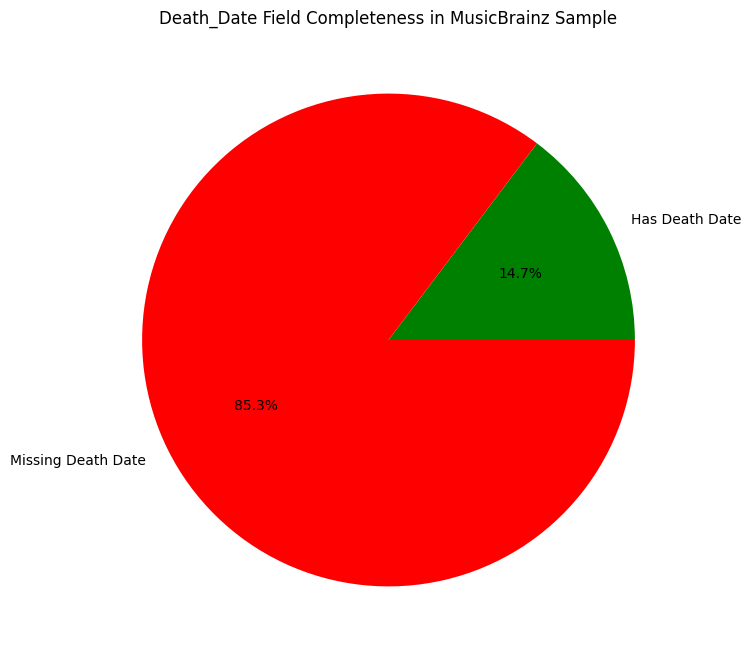

In [27]:
completeness_data = pd.Series({
    'Has Death Date': has_death_date,
    'Missing Death Date': missing_death_date
})

completeness_data.plot(
    kind='pie',
    autopct='%.1f%%',
    title='Death_Date Field Completeness in MusicBrainz Sample',
    figsize=(8, 8),
    colors=['#008000', '#FF0000']
)
plt.show()

**Analysing Completeness of `Death_Date` Field in comparison to Other Fields**

In [28]:
print("Rows returned:", len(df_musicbrainz))

missing_summary = df_musicbrainz.isna().mean().sort_values(ascending=False) * 100
missing_summary.to_frame("percent_missing").round(1)

Rows returned: 34


,percent_missing
death_date,85.3
birth_date,41.2
country,41.2
name,0.0
type,0.0


**Disadvantage** The death date completeness analysis reveals a severe limitation - even from our limited dataset of 50 artists, we see that approximately 85% of queried artists lack documented death dates in MusicBrainz and this can be generalized to some extent to the rest of the data we have not extracted. This lack of completeness is problematic for our project, which requires death dates as the anchor for measuring posthumous streaming effects.

###Data Quality Consideration

**Completeness**
The MusicBrainz dataset shows low completeness for fields that are critical to our analysis. While artist names are consistently available, death dates are missing for a large majority of artists. MusicBrainz primarily focuses on cataloguing musical works and credits rather than maintaining full biographical records. As a result, many artists - especially less prominent ones - do not have a recorded death date. Since the death date is the key reference point for measuring posthumous changes in music consumption, this level of incompleteness significantly limits the dataset’s usefulness for our study.

**Consistency**
MusicBrainz records are stored in a structured and standardized format, with consistent field names across artists. However, a major consistency issue arises from how artist roles are represented. MusicBrainz uses a broad definition of “artist” that includes not only musicians and composers, but also producers, engineers, photographers, and other contributors credited on releases. Unlike Wikidata, MusicBrainz does not provide a clear, structured occupation field. Instead, it relies on user-generated tags (e.g., “composer”, “musician”), which are applied inconsistently and are not guaranteed to be present. This makes it difficult to reliably filter for relevant musical roles in a systematic way.

**Granularity**
The dataset is recorded at the individual artist level, which is appropriate in principle for linking artist deaths to time-series data such as streaming counts or chart performance. However, because role information is unreliable and death dates are often missing, the effective granularity of usable data is much lower than expected. Many returned records represent individuals whose deaths are either unknown or irrelevant to music consumption analysis, reducing the number of valid observations that can be used.


###Conclusion
MusicBrainz is not suitable as a primary biographical data source for this project. Although it provides high-quality information on musical works and credits, it lacks complete and reliable biographical data - particularly death dates - which are essential for posthumous consumption analysis. The absence of structured occupation fields and the reliance on inconsistent user-generated tags further limit our ability to accurately identify relevant musicians at scale. To use this, extensive filtering and cleaning will be required but even after that, the resulting dataset would be small and difficult to generalize. Therefore, MusicBrainz is not selected for use in this study, and Wikidata remains the preferred source for artist biographical metadata.

#DS6: Billboard Charts API

###Description

The Billboard Charts dataset was accessed using the billboard.py Python library, which scrapes publicly available Billboard chart rankings such as the Hot 100. This dataset provides weekly chart positions for songs, including rank, number of weeks on chart, peak position, and artist name. Unlike biographical datasets such as Wikidata, Billboard data reflects music consumption outcomes in the form of chart performance, which is influenced by sales, radio play, and streaming.

In this project, the Billboard dataset is explored as a potential source to capture changes in mainstream popularity before and after an artist’s death. Chart presence can serve as a proxy for consumption, especially for well-known artists whose songs may re-enter charts or improve in ranking following posthumous media attention.

In [29]:
!pip -q install billboard.py pandas
import billboard
from datetime import timedelta

In [30]:
def to_chart_week_date(d):
    days_until_sat = (5 - d.weekday()) % 7  # Monday=0 ... Saturday=5
    return d + timedelta(days=days_until_sat)

def get_artist_entries_for_week(artist_name, chart_week_date, chart_name="hot-100"):
    try:
        chart = billboard.ChartData(chart_name, date=chart_week_date.strftime("%Y-%m-%d"))
    except Exception as e:
        print(f"  -> Error fetching chart for {chart_week_date}: {e}")
        return []

    rows = []
    for song in chart:
        # simple matching rule (works for many cases; can be improved later)
        if artist_name.lower() in song.artist.lower():
            rows.append({
                "week": chart_week_date,
                "title": song.title,
                "artist_credit": song.artist,
                "rank": song.rank,
                "weeks_on_chart": song.weeks
            })
    return rows

def collect_window(artist_name, anchor_date, weeks_before=4, weeks_after=4, chart_name="hot-100"):
    start = anchor_date - timedelta(weeks=weeks_before)
    end   = anchor_date + timedelta(weeks=weeks_after)

    weeks = []
    cur = start
    while cur <= end:
        weeks.append(to_chart_week_date(cur))
        cur += timedelta(weeks=1)

    weeks = sorted(set(weeks))
    print(f"\n=== {artist_name} | {chart_name} ===")
    print(f"Weeks queried: {len(weeks)} | {weeks[0]} to {weeks[-1]}")

    all_rows = []
    for wk in weeks:
        print(f"Fetching week of {wk}...")
        all_rows.extend(get_artist_entries_for_week(artist_name, wk, chart_name=chart_name))

    df = pd.DataFrame(all_rows)
    if len(df) > 0:
        df["week"] = pd.to_datetime(df["week"])
        df = df.sort_values(["week", "rank"]).reset_index(drop=True)

    print(f"Collected {len(df)} chart entries for {artist_name}")
    return df


In [31]:
# list of artists who died (anchor points)
mj_death   = datetime.date(2009, 6, 25)
xxx_death  = datetime.date(2018, 6, 18)
wh_death   = datetime.date(2012, 2, 11)

# chart collection (Billboard Hot 100)
df_mj  = collect_window("Michael Jackson", mj_death,  weeks_before=4, weeks_after=4, chart_name="hot-100")
df_xxx = collect_window("XXXTENTACION",   xxx_death, weeks_before=4, weeks_after=4, chart_name="hot-100")
df_wh  = collect_window("Whitney Houston", wh_death, weeks_before=4, weeks_after=4, chart_name="hot-100")

# lady gaga (very much alive) — this example is just to prove historic access works
gaga_anchor = datetime.date(2011, 1, 15)
df_gaga = collect_window("Lady Gaga", gaga_anchor, weeks_before=4, weeks_after=4, chart_name="hot-100")



=== Michael Jackson | hot-100 ===
Weeks queried: 9 | 2009-05-30 to 2009-07-25
Fetching week of 2009-05-30...
Fetching week of 2009-06-06...
Fetching week of 2009-06-13...
Fetching week of 2009-06-20...
Fetching week of 2009-06-27...
Fetching week of 2009-07-04...
Fetching week of 2009-07-11...
Fetching week of 2009-07-18...
Fetching week of 2009-07-25...
Collected 0 chart entries for Michael Jackson

=== XXXTENTACION | hot-100 ===
Weeks queried: 9 | 2018-05-26 to 2018-07-21
Fetching week of 2018-05-26...
Fetching week of 2018-06-02...
Fetching week of 2018-06-09...
Fetching week of 2018-06-16...
Fetching week of 2018-06-23...
Fetching week of 2018-06-30...
Fetching week of 2018-07-07...
Fetching week of 2018-07-14...
Fetching week of 2018-07-21...
Collected 36 chart entries for XXXTENTACION

=== Whitney Houston | hot-100 ===
Weeks queried: 9 | 2012-01-14 to 2012-03-10
Fetching week of 2012-01-14...
Fetching week of 2012-01-21...
Fetching week of 2012-01-28...
Fetching week of 2012-02-

In [32]:
rihanna_anchor = datetime.date(2011, 1, 15)
df_rihanna = collect_window("Rihanna", gaga_anchor, weeks_before=4, weeks_after=4, chart_name="hot-100")


=== Rihanna | hot-100 ===
Weeks queried: 9 | 2010-12-18 to 2011-02-12
Fetching week of 2010-12-18...
Fetching week of 2010-12-25...
Fetching week of 2011-01-01...
Fetching week of 2011-01-08...
Fetching week of 2011-01-15...
Fetching week of 2011-01-22...
Fetching week of 2011-01-29...
Fetching week of 2011-02-05...
Fetching week of 2011-02-12...
Collected 30 chart entries for Rihanna


In [33]:
def show_entries(df, artist_name, n=30):
    print(f"\n=== {artist_name} ({len(df)} chart entries) ===")
    if df.empty:
        print("No rows to show.")
    else:
        display(df.head(n))

show_entries(df_mj, "Michael Jackson")
show_entries(df_xxx, "XXXTENTACION")
show_entries(df_wh, "Whitney Houston")
show_entries(df_gaga, "Lady Gaga")
show_entries(df_rihanna, "Rihanna")



=== Michael Jackson (0 chart entries) ===
No rows to show.

=== XXXTENTACION (36 chart entries) ===


,week,title,artist_credit,rank,weeks_on_chart
0,2018-05-26,Sad!,XXXTENTACION,27,11
1,2018-05-26,Moonlight,XXXTENTACION,88,7
2,2018-06-02,Sad!,XXXTENTACION,32,12
3,2018-06-02,Moonlight,XXXTENTACION,94,8
4,2018-06-09,Sad!,XXXTENTACION,43,13
5,2018-06-09,Moonlight,XXXTENTACION,99,9
6,2018-06-16,Sad!,XXXTENTACION,51,14
7,2018-06-23,Sad!,XXXTENTACION,52,15
8,2018-06-30,Sad!,XXXTENTACION,1,16
9,2018-06-30,Moonlight,XXXTENTACION,16,10



=== Whitney Houston (8 chart entries) ===


,week,title,artist_credit,rank,weeks_on_chart
0,2012-02-25,I Will Always Love You,Whitney Houston,7,27
1,2012-02-25,I Wanna Dance With Somebody (Who Loves Me),Whitney Houston,35,19
2,2012-02-25,Greatest Love Of All,Whitney Houston,41,19
3,2012-03-03,I Will Always Love You,Whitney Houston,3,28
4,2012-03-03,I Wanna Dance With Somebody (Who Loves Me),Whitney Houston,25,20
5,2012-03-03,Greatest Love Of All,Whitney Houston,36,20
6,2012-03-03,How Will I Know,Whitney Houston,49,24
7,2012-03-10,I Will Always Love You,Whitney Houston,30,29



=== Lady Gaga (0 chart entries) ===
No rows to show.

=== Rihanna (30 chart entries) ===


,week,title,artist_credit,rank,weeks_on_chart
0,2010-12-18,What's My Name?,Rihanna Featuring Drake,3,7
1,2010-12-18,Only Girl (In The World),Rihanna,6,13
2,2010-12-18,Love The Way You Lie,Eminem Featuring Rihanna,37,24
3,2010-12-25,What's My Name?,Rihanna Featuring Drake,2,8
4,2010-12-25,Only Girl (In The World),Rihanna,6,14
5,2010-12-25,Love The Way You Lie,Eminem Featuring Rihanna,40,25
6,2011-01-01,What's My Name?,Rihanna Featuring Drake,3,9
7,2011-01-01,Only Girl (In The World),Rihanna,7,15
8,2011-01-01,Love The Way You Lie,Eminem Featuring Rihanna,44,26
9,2011-01-08,What's My Name?,Rihanna Featuring Drake,4,10


###Data Quality Consideration

**Completeness**
Based on exploratory querying, the dataset shows reasonable completeness for charting artists, including historical periods such as 2009–2010. For example, querying artists like Rihanna during this time range successfully returns chart records, indicating that historical data is accessible through the API for artists who actively charted.

As Billboard charts only record songs that entered the rankings, the absence of records for a given artist in a specific period can plausibly be interpreted as the artist not charting during that time, rather than missing data. However, because this assumption is critical to the analysis, it is important to verify the historical depth and consistency of accessible data across different years and artists. This verification step ensures that “no records found” genuinely reflects a lack of chart presence rather than technical limitations.

**Consistency**
When data is available, chart entries are presented in a highly consistent format, with standardized fields for rank, weeks on chart, peak position, and artist attribution. Charts are published on a regular weekly basis, which supports longitudinal analysis and makes it possible to track changes in chart performance over time.

Artist names occasionally appear with variations (e.g. featured artists or collaborations), but this is a manageable issue that can be addressed through preprocessing and string matching. Overall, the dataset is structurally consistent and well-suited for time-series analysis.

**Granularity**
The dataset operates at a song–week level, providing fine-grained temporal detail. This granularity allows us to observe:

*   Chart re-entries following an artist’s death
*   Changes in ranking positions over consecutive weeks
*   Differences in persistence (how long songs remain on charts)

By aggregating song-level records, we can also derive artist-level indicators, such as total chart appearances, average rank, or weeks on chart before and after death. This flexibility makes the dataset analytically powerful for studying posthumous consumption patterns.

**Temporal Alignment**
A key strength of the Billboard dataset is its long historical coverage, which extends well into the modern streaming era. This allows us to align chart data with artist death dates and compare pre-death and post-death periods within a consistent framework.

Because chart data exists for the same weekly structure across decades, it supports clean temporal comparisons, which are essential for identifying posthumous effects. The dataset is therefore temporally compatible with the goals of this project, provided that the accessible historical range is confirmed through further validation.


**Accessibility and Maintenance Considerations**
The Billboard data accessed via billboard.py is retrieved through web scraping of publicly available charts. This means the dataset does not require paid access or API keys, which is a practical advantage for academic projects. However, it also implies that continued functionality depends on the external website structure remaining stable and the library being maintained by its developer.

This is not an immediate limitation for the current analysis, but it is a factor to be aware of when considering long-term or large-scale automated data collection.

###Conclusion
The Billboard Charts dataset is a strong candidate for analysing posthumous changes in mainstream music consumption. Its structured weekly rankings, fine temporal granularity, and demonstrated accessibility to historical data make it well-suited for comparing chart performance before and after an artist’s death.

While it is necessary to verify the historical depth of available data to confidently interpret missing records, initial exploration suggests that the dataset reliably reflects chart presence for artists who were actively popular during the queried periods. The main limitations - dependence on web scraping and focus on mainstream charting artists - do not undermine its usefulness for this project’s objectives.

Overall, Billboard charts provide a valuable quantitative signal of consumption outcomes and serve as a strong complement to discovery-based datasets such as Google Trends and Last.fm in understanding posthumous music consumption patterns.

## Data Preparation (Process)

> *In this section, we describe, justify, and implement transformation and profiling tasks to prepare the data selected during exploration for later analysis.*

### Overview

As part of data preparation, we implement the following transformation and profiling tasks:

1. **Artist Selection (Structuring):** We query Wikidata for deceased musicians, then rank them by average daily Wikipedia page views as a proxy for global notability. We curate a focused set of ~50 well-known artists likely to have presence across all three data sources.

2. **Data Collection & Integration:** For each selected artist, we collect

    i. biographical data (Wikidata),

    ii. Billboard Hot 100 chart entries (4 weeks pre-death to 12 weeks post-death), and
    
    iii. Google Trends search interest over the same window.
  
    These are integrated into a unified SQLite database using artist name and date as join keys.

3. **Profiling & Cleaning:** We profile missing values, handle duplicate artist entries from multi-genre tagging, standardize date formats, and resolve categorical inconsistencies.

4. **Feature Engineering (Enrichment):** We derive analytical columns including `age_at_death`, `popularity_spike`, `chart_entries_before`/`chart_entries_after`, grouped `genre_category`, and `death_era`.

5. **Final Profiling:** We verify quality and distribution of all features prior to analysis.

### Step 1: Artist Selection from Wikidata

We query Wikidata for deceased musicians born after 1920 who died after 1970, ranking them by their number of Wikipedia page views as a proxy for global notability. This allows us to systematically identify well-known artists who are most likely to have measurable presence across Billboard charts and Google search trends.

We retrieve 500 candidates and will curate approximately 50 from this pool.

In [34]:
# Query Wikidata for deceased musicians with stricter filtering
# Require both a musician occupation AND a music genre tag to filter out non-musicians
query_curated = """
SELECT DISTINCT ?artist ?artistLabel ?birthDate ?deathDate
       ?genreLabel ?countryLabel
WHERE {
  ?artist wdt:P31 wd:Q5 .
  ?artist wdt:P106 ?occupation .
  VALUES ?occupation {
    wd:Q177220   # singer
    wd:Q639669   # musician
    wd:Q488205   # singer-songwriter
    wd:Q36834    # composer
    wd:Q855091   # guitarist
    wd:Q386854   # drummer
    wd:Q584301   # pianist (musician)
    wd:Q2252262  # rapper
    wd:Q183945   # record producer
    wd:Q753110   # songwriter
  }
  ?artist wdt:P136 ?genre .
  ?artist wdt:P569 ?birthDate .
  ?artist wdt:P570 ?deathDate .
  OPTIONAL { ?artist wdt:P27 ?country . }

  FILTER(YEAR(?deathDate) >= 1970)
  FILTER(YEAR(?birthDate) >= 1920)

  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 1500
"""

sparql.setQuery(query_curated)
sparql.setReturnFormat(JSON)

import urllib.error

for attempt in range(3):
    try:
        print(f"Querying Wikidata (attempt {attempt + 1})...")
        results = sparql.query().convert()
        print("Query successful!")
        break
    except urllib.error.HTTPError as e:
        if attempt < 2:
            print(f"Timeout/error ({e}), retrying in 10s...")
            time.sleep(10)
        else:
            raise Exception("Wikidata query failed after 3 attempts. Try again later.")

# Convert to DataFrame
data_rows = []
for result in results['results']['bindings']:
    row = {
        'artist_id': result['artist']['value'].split('/')[-1],
        'artist_name': result.get('artistLabel', {}).get('value', 'Unknown'),
        'birth_date': result.get('birthDate', {}).get('value', None),
        'death_date': result.get('deathDate', {}).get('value', None),
        'genre': result.get('genreLabel', {}).get('value', 'Unknown'),
        'country': result.get('countryLabel', {}).get('value', 'Unknown'),
    }
    data_rows.append(row)

df_candidates = pd.DataFrame(data_rows)
print(f"Total rows returned: {len(df_candidates)}")
print(f"Unique artists: {df_candidates['artist_name'].nunique()}")
df_candidates.head(20)

Querying Wikidata (attempt 1)...
Query successful!
Total rows returned: 1500
Unique artists: 489


,artist_id,artist_name,birth_date,death_date,genre,country
0,Q48987,Jonathan Demme,1944-02-22T00:00:00Z,2017-04-26T00:00:00Z,thriller film,United States
1,Q29544,Delia Derbyshire,1937-05-05T00:00:00Z,2001-07-03T00:00:00Z,electronic music,United Kingdom
2,Q44315,Hide,1964-12-13T00:00:00Z,1998-05-02T00:00:00Z,heavy metal music,Japan
3,Q57396,Ivan Rebroff,1931-07-31T00:00:00Z,2008-02-27T00:00:00Z,variety,Germany
4,Q48987,Jonathan Demme,1944-02-22T00:00:00Z,2017-04-26T00:00:00Z,crime drama film,United States
5,Q48987,Jonathan Demme,1944-02-22T00:00:00Z,2017-04-26T00:00:00Z,drama film,United States
6,Q1203,John Lennon,1940-10-09T00:00:00Z,1980-12-08T00:00:00Z,beat music,United Kingdom
7,Q512,Vladimir Vysotsky,1938-01-25T00:00:00Z,1980-07-25T00:00:00Z,prose,Soviet Union
8,Q34580,Ichirō Mizuki,1948-01-07T00:00:00Z,2022-12-06T00:00:00Z,kayōkyoku,Japan
9,Q1203,John Lennon,1940-10-09T00:00:00Z,1980-12-08T00:00:00Z,blues rock,United Kingdom


### Handling Multi-Genre Duplicates

Artists in Wikidata often have multiple genre tags, producing duplicate rows. We aggregate genres per artist into a single comma-separated field, keeping the highest sitelinks count.

In [35]:
# Aggregate: group genres per artist, keep first value for other fields
df_unique = df_candidates.groupby('artist_id').agg({
    'artist_name': 'first',
    'birth_date': 'first',
    'death_date': 'first',
    'genre': lambda x: ', '.join(sorted(set(x))),
    'country': 'first',
}).reset_index()

# Since we no longer have sitelinks from the query, we use a Wikipedia API call
# to get page views as a fame proxy
import requests

def get_wikipedia_pageviews(artist_name):
    """Get average daily Wikipedia page views (last 60 days) as a fame proxy."""
    title = artist_name.replace(' ', '_')
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/{title}/daily/20250101/20250301"
    try:
        resp = requests.get(url, headers={"User-Agent": "SC3021 Student Project/1.0"}, timeout=10)
        if resp.status_code == 200:
            items = resp.json().get('items', [])
            if items:
                return sum(i['views'] for i in items) / len(items)
    except:
        pass
    return 0

print("Fetching Wikipedia page views as fame proxy (this takes ~1-2 minutes)...")
df_unique['pageviews'] = df_unique['artist_name'].apply(get_wikipedia_pageviews)

df_unique = df_unique.sort_values('pageviews', ascending=False).reset_index(drop=True)
print(f"Unique artists after deduplication: {len(df_unique)}")
df_unique.head(30)

Fetching Wikipedia page views as fame proxy (this takes ~1-2 minutes)...
Unique artists after deduplication: 489


,artist_id,artist_name,birth_date,death_date,genre,country,pageviews
0,Q15869,Freddie Mercury,1946-09-05T00:00:00Z,1991-11-24T00:00:00Z,"classic rock, classical crossover, disco, glam...",Sultanate of Zanzibar,14307.933333
1,Q1203,John Lennon,1940-10-09T00:00:00Z,1980-12-08T00:00:00Z,"art rock, beat music, blues rock, experimental...",United Kingdom,11899.050000
2,Q15897,Amy Winehouse,1983-09-14T00:00:00Z,2011-07-23T00:00:00Z,"blue-eyed soul, contemporary R&B, jazz, neo so...",United Kingdom,10495.783333
3,Q8446,Kurt Cobain,1967-02-20T00:00:00Z,1994-04-05T00:00:00Z,"alternative rock, grunge",United States,9585.483333
4,Q130311,George Michael,1963-06-25T00:00:00Z,2016-12-25T00:00:00Z,"adult contemporary music, blue-eyed soul, cont...",United Kingdom,8166.366667
5,Q125121,Aretha Franklin,1942-03-25T00:00:00Z,2018-08-16T00:00:00Z,"funk, gospel music, jazz, pop music, pop rock,...",United States,7405.250000
6,Q150651,George Carlin,1937-05-12T00:00:00Z,2008-06-22T00:00:00Z,"black comedy, character comedy, irony, observa...",United States,6219.366667
7,Q105460,John Denver,1943-12-31T00:00:00Z,1997-10-12T00:00:00Z,"country music, folk music, folk rock, folk-pop...",United States,5498.583333
8,Q155407,Jean-Michel Basquiat,1960-12-22T00:00:00Z,1988-08-12T00:00:00Z,"figurative art, graffiti",United States,5449.166667
9,Q127330,Frank Zappa,1940-12-21T00:00:00Z,1993-12-04T00:00:00Z,"alternative rock, art music, avant-garde music...",United States,5090.933333


### Curating the Final Artist Set

We select the top 50 artists by average daily Wikipedia page views. This ensures we pick the most globally notable deceased musicians, who are most likely to have measurable Billboard and Google Trends presence.

In [36]:
# Select top 50 most notable artists
df_artists = df_unique.head(50).copy()

# Clean date fields
df_artists['birth_date'] = pd.to_datetime(df_artists['birth_date'], errors='coerce')
df_artists['death_date'] = pd.to_datetime(df_artists['death_date'], errors='coerce')

# Store in SQLite
df_artists.to_sql('artists', conn, if_exists='replace', index=False)

print(f"Selected {len(df_artists)} artists for analysis.")
print(f"Death year range: {df_artists['death_date'].dt.year.min()} - {df_artists['death_date'].dt.year.max()}")
print(f"\nArtist list:")
for i, row in df_artists.iterrows():
    print(f"  {row['artist_name']} (d. {row['death_date'].strftime('%Y-%m-%d') if pd.notna(row['death_date']) else '?'})")

Selected 50 artists for analysis.
Death year range: 1978 - 2025

Artist list:
  Freddie Mercury (d. 1991-11-24)
  John Lennon (d. 1980-12-08)
  Amy Winehouse (d. 2011-07-23)
  Kurt Cobain (d. 1994-04-05)
  George Michael (d. 2016-12-25)
  Aretha Franklin (d. 2018-08-16)
  George Carlin (d. 2008-06-22)
  John Denver (d. 1997-10-12)
  Jean-Michel Basquiat (d. 1988-08-12)
  Frank Zappa (d. 1993-12-04)
  Jeff Beck (d. 2023-01-10)
  Robbie Robertson (d. 2023-08-09)
  Miles Davis (d. 1991-09-28)
  Roy Orbison (d. 1988-12-06)
  Stevie Ray Vaughan (d. 1990-08-27)
  Paul Allen (d. 2018-10-15)
  Waylon Jennings (d. 2002-02-13)
  Rick James (d. 2004-08-06)
  Ravi Shankar (d. 2012-12-11)
  Glen Campbell (d. 2017-08-08)
  Stephen Sondheim (d. 2021-11-26)
  Gil Scott-Heron (d. 2011-05-27)
  Gene Pitney (d. 2006-04-05)
  Sergio Leone (d. 1989-04-30)
  Ray Manzarek (d. 2013-05-20)
  Mark Lanegan (d. 2022-02-22)
  Mohammed Rafi (d. 1980-07-31)
  Serge Gainsbourg (d. 1991-03-02)
  Jimmy Cliff (d. 2025-1

### Step 2: Wikipedia Page View History Collection

For each selected artist, we collect daily Wikipedia page view data spanning 4 weeks (28 days) before to 12 weeks (84 days) after their death date. Wikipedia page views serve as a strong proxy for public attention — when someone dies, people look them up on Wikipedia.

This data source has several advantages over Billboard chart data (which we explored in the Prepare stage):
- **Universal coverage**: every artist in our Wikidata set has a Wikipedia page
- **Daily granularity**: finer-grained than Billboard's weekly chart cycles
- **Global scope**: captures worldwide attention, not just US chart activity
- **No rate limits**: the Wikimedia REST API is free and well-documented

**Limitation:** The Wikimedia pageview API only provides data from July 2015 onwards. Artists who died before mid-2015 will not have page view data, which reduces our usable sample. We document this filtering below.

In [37]:
def get_wiki_pageviews_window(artist_name, death_date, days_before=28, days_after=84):
    """
    Collect daily Wikipedia page views for an artist in a window around their death.
    Uses the Wikimedia REST API (available from July 2015 onwards).
    Returns a DataFrame with columns: date, views, artist_name, period
    """
    title = artist_name.replace(' ', '_')
    start = (death_date - timedelta(days=days_before)).strftime('%Y%m%d')
    end = (death_date + timedelta(days=days_after)).strftime('%Y%m%d')

    url = (f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
           f"en.wikipedia/all-access/all-agents/{title}/daily/{start}/{end}")

    try:
        resp = requests.get(url, headers={"User-Agent": "SC3021 Student Project/1.0"}, timeout=15)
        if resp.status_code == 200:
            items = resp.json().get('items', [])
            rows = []
            for item in items:
                date = pd.to_datetime(item['timestamp'][:8])
                period = 'pre' if date.date() < death_date else 'post'
                rows.append({
                    'date': date,
                    'views': item['views'],
                    'artist_name': artist_name,
                    'period': period
                })
            return pd.DataFrame(rows)
        else:
            return pd.DataFrame()
    except Exception as e:
        print(f"    Error: {e}")
        return pd.DataFrame()

In [38]:
# Collect Wikipedia page view data for all selected artists
all_wiki_views = []
wiki_errors = []
skipped_pre_2015 = []

for idx, row in df_artists.iterrows():
    name = row['artist_name']
    death = row['death_date']

    if pd.isna(death):
        print(f"[SKIP] {name} — missing death date")
        continue

    death_dt = death.date() if hasattr(death, 'date') else death

    # Wikimedia API only has data from July 2015
    if death_dt < datetime.date(2015, 7, 1):
        print(f"[SKIP] {name} (d. {death_dt}) — died before Wikimedia pageview API coverage")
        skipped_pre_2015.append(name)
        continue

    print(f"[{idx+1}/{len(df_artists)}] Wikipedia views for {name} (d. {death_dt})...")

    df_wiki = get_wiki_pageviews_window(name, death_dt)

    if not df_wiki.empty:
        all_wiki_views.append(df_wiki)
        print(f"  -> {len(df_wiki)} daily readings, peak: {df_wiki['views'].max():,} views")
    else:
        print(f"  -> No data returned")
        wiki_errors.append(name)

    time.sleep(0.5)  # light rate limiting

# Combine all results
df_wiki_views = pd.concat(all_wiki_views, ignore_index=True) if all_wiki_views else pd.DataFrame()

print(f"\n=== Wikipedia Page Views Collection Complete ===")
print(f"Total daily readings: {len(df_wiki_views)}")
print(f"Artists with data: {df_wiki_views['artist_name'].nunique()}")
print(f"Skipped (pre-2015 deaths): {len(skipped_pre_2015)}")
if wiki_errors:
    print(f"Errors: {wiki_errors}")

[SKIP] Freddie Mercury (d. 1991-11-24) — died before Wikimedia pageview API coverage
[SKIP] John Lennon (d. 1980-12-08) — died before Wikimedia pageview API coverage
[SKIP] Amy Winehouse (d. 2011-07-23) — died before Wikimedia pageview API coverage
[SKIP] Kurt Cobain (d. 1994-04-05) — died before Wikimedia pageview API coverage
[5/50] Wikipedia views for George Michael (d. 2016-12-25)...
  -> 113 daily readings, peak: 4,286,180 views
[6/50] Wikipedia views for Aretha Franklin (d. 2018-08-16)...
  -> 113 daily readings, peak: 2,046,677 views
[SKIP] George Carlin (d. 2008-06-22) — died before Wikimedia pageview API coverage
[SKIP] John Denver (d. 1997-10-12) — died before Wikimedia pageview API coverage
[SKIP] Jean-Michel Basquiat (d. 1988-08-12) — died before Wikimedia pageview API coverage
[SKIP] Frank Zappa (d. 1993-12-04) — died before Wikimedia pageview API coverage
[11/50] Wikipedia views for Jeff Beck (d. 2023-01-10)...
  -> 113 daily readings, peak: 1,204,044 views
[12/50] Wikipe

Here, we add a checkpoint saver that saves successful Wikipedia page views data into a csv file which you can reload so that you don't have to re-run the full query again.

In [39]:
# === CHECKPOINT: Save Wikipedia page view data ===
df_wiki_views.to_csv('wiki_views_checkpoint.csv', index=False)
df_wiki_views.to_sql('wiki_views', conn, if_exists='replace', index=False)

print(f"Saved {len(df_wiki_views)} page view readings to wiki_views_checkpoint.csv")

# === UNCOMMENT TO RELOAD ===
# df_wiki_views = pd.read_csv('wiki_views_checkpoint.csv')
# df_wiki_views['date'] = pd.to_datetime(df_wiki_views['date'])
# print(f"Reloaded {len(df_wiki_views)} page view readings from checkpoint.")

Saved 1808 page view readings to wiki_views_checkpoint.csv


### Reload from Checkpoint (if needed)

If the notebook was restarted after Wikipedia page view data was already collected, uncomment and run the cell above to reload from saved CSV files.

In [40]:
# === CHECKPOINT: Save Wikipedia page view data ===
df_wiki_views.to_csv('wiki_views_checkpoint.csv', index=False)
df_wiki_views.to_sql('wiki_views', conn, if_exists='replace', index=False)

print(f"Saved {len(df_wiki_views)} page view readings to wiki_views_checkpoint.csv")

# === UNCOMMENT TO RELOAD ===
# df_wiki_views = pd.read_csv('wiki_views_checkpoint.csv')
# df_wiki_views['date'] = pd.to_datetime(df_wiki_views['date'])
# print(f"Reloaded {len(df_wiki_views)} page view readings from checkpoint.")

Saved 1808 page view readings to wiki_views_checkpoint.csv


### Profiling Wikipedia Page View Data

We examine the distribution of page views across artists and verify that the data captures meaningful pre/post-death patterns. A key indicator of data quality is whether we observe a visible page view spike around the death date.

Wikipedia page view summary per artist:


,artist_name,readings,pre_mean,post_mean,peak,spike_ratio
10,Mark Sheehan,113,14.571429,2413.670588,43435,165.64
9,Mark Lanegan,113,667.107143,12750.788235,344618,19.11
4,George Michael,113,7220.892857,113917.117647,4286180,15.78
2,David Sanborn,113,334.035714,4313.341176,112343,12.91
7,Jimmy Cliff,113,501.285714,6361.917647,224722,12.69
6,Jeff Beck,113,3188.000000,35230.576471,1204044,11.05
3,Fats Domino,113,1151.285714,10656.600000,351325,9.26
8,John Mayall,113,630.035714,5254.105882,167628,8.34
15,Vangelis,113,964.214286,7840.117647,176216,8.13
0,André Previn,113,709.821429,5336.611765,117872,7.52


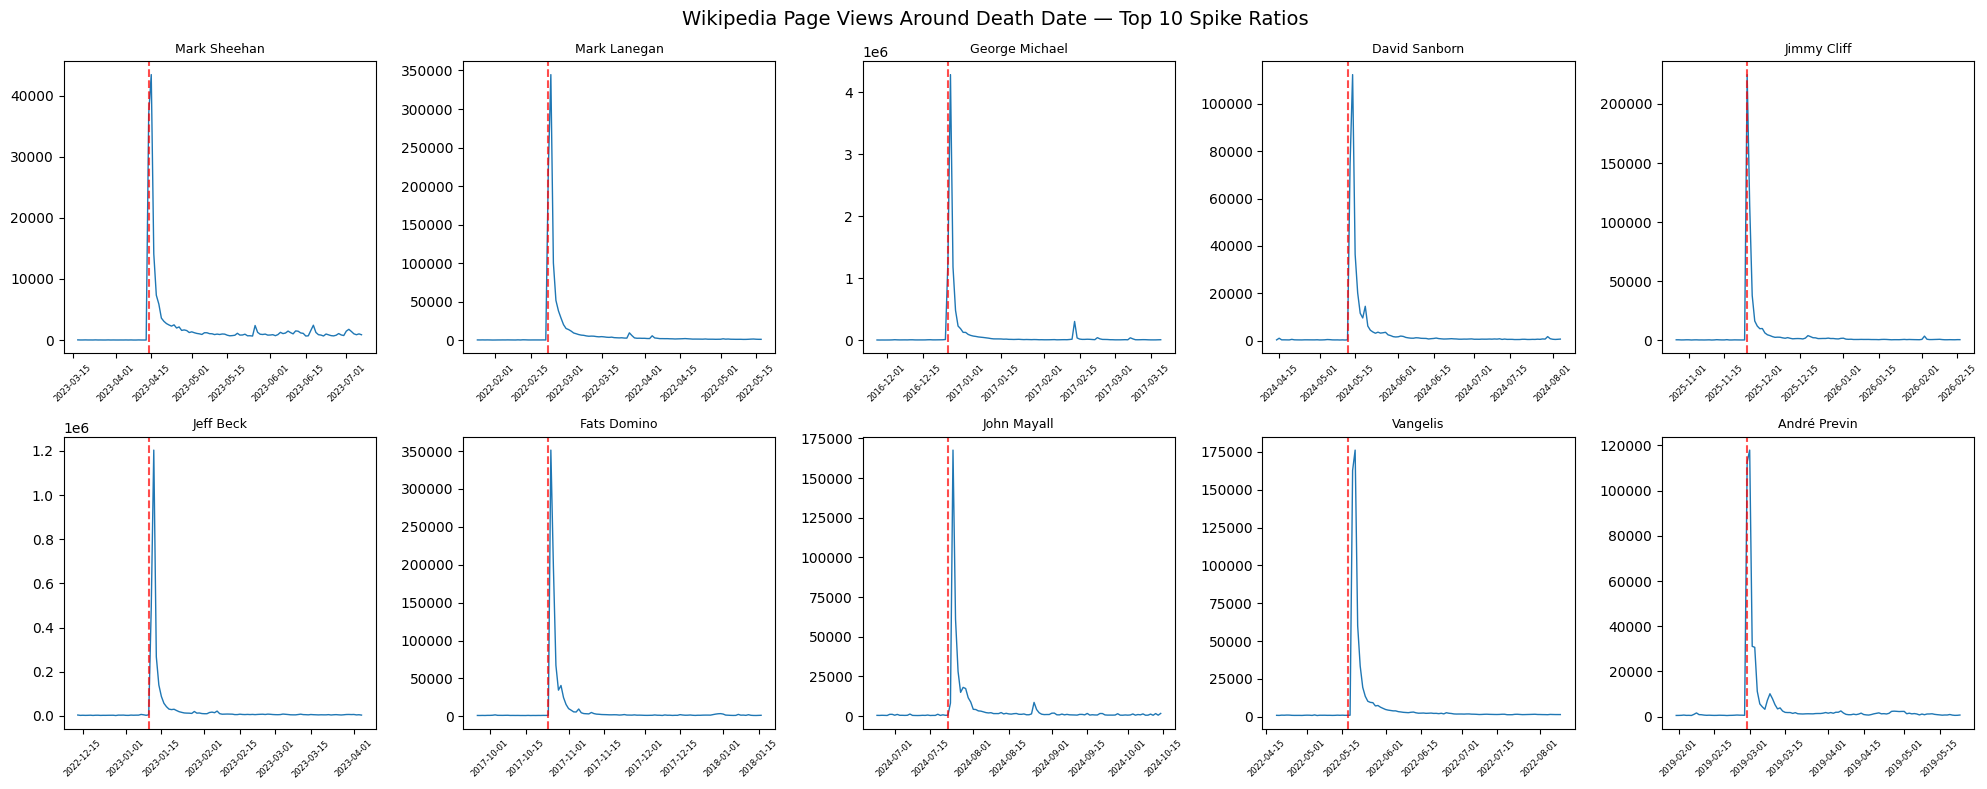

In [41]:
import numpy as np
# Summary per artist
wiki_summary = df_wiki_views.groupby('artist_name').agg(
    readings=('views', 'count'),
    pre_mean=('views', lambda x: x[df_wiki_views.loc[x.index, 'period'] == 'pre'].mean()),
    post_mean=('views', lambda x: x[df_wiki_views.loc[x.index, 'period'] == 'post'].mean()),
    peak=('views', 'max')
).reset_index()

wiki_summary['spike_ratio'] = (wiki_summary['post_mean'] / wiki_summary['pre_mean'].replace(0, np.nan)).round(2)
wiki_summary = wiki_summary.sort_values('spike_ratio', ascending=False)

print("Wikipedia page view summary per artist:")
display(wiki_summary)

# Visualize: top 10 artists by spike ratio
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Wikipedia Page Views Around Death Date — Top 10 Spike Ratios', fontsize=14)
top_spike = wiki_summary.head(10)

for i, (_, artist_row) in enumerate(top_spike.iterrows()):
    ax = axes[i // 5][i % 5]
    artist_data = df_wiki_views[df_wiki_views['artist_name'] == artist_row['artist_name']].sort_values('date')
    death_date = df_artists[df_artists['artist_name'] == artist_row['artist_name']]['death_date'].iloc[0]

    ax.plot(artist_data['date'], artist_data['views'], linewidth=1)
    ax.axvline(x=death_date, color='red', linestyle='--', alpha=0.7)
    ax.set_title(artist_row['artist_name'], fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=6)

plt.tight_layout()
plt.show()

### Step 3: Google Trends Data Collection

For each selected artist, we collect weekly Google Trends search interest data spanning 4 weeks before to 12 weeks after their death date. Google Trends returns a relative interest score (0–100) normalised to the peak value within each individual query's timeframe.

**Important limitation:** Because Google Trends normalises scores per query, the value "100" for one artist represents their personal peak, not an absolute measure comparable across artists. We address this in our analysis by focusing on the *shape* of each artist's trend curve (i.e., the ratio of post-death to pre-death interest) rather than raw values.

We use the `pytrends` library and include delays between requests to manage Google's rate limiting.

In [42]:
# Google Trends collection with rate-limit handling
pytrends = TrendReq(hl='en-US', tz=360)

all_trends = []
trend_errors = []

for idx, row in df_artists.iterrows():
    name = row['artist_name']
    death = row['death_date']

    if pd.isna(death):
        print(f"[SKIP] {name} — missing death date")
        continue

    death_dt = death.date() if hasattr(death, 'date') else death

    # Define timeframe: 4 weeks before to 12 weeks after death
    start = death_dt - timedelta(weeks=4)
    end = death_dt + timedelta(weeks=12)
    timeframe = f"{start.strftime('%Y-%m-%d')} {end.strftime('%Y-%m-%d')}"

    print(f"[{idx+1}/{len(df_artists)}] Google Trends for {name} ({timeframe})...")

    success = False
    for attempt in range(3):
        try:
            pytrends.build_payload([name], timeframe=timeframe, geo='')
            trend_df = pytrends.interest_over_time()

            if not trend_df.empty:
                trend_df = trend_df.reset_index()
                trend_df = trend_df[['date', name]].rename(columns={name: 'interest'})
                trend_df['artist_name'] = name
                trend_df['period'] = trend_df['date'].apply(
                    lambda d: 'pre' if d.date() < death_dt else 'post'
                )

                # If daily data returned, resample to weekly
                if len(trend_df) > 20:
                    trend_df['date'] = pd.to_datetime(trend_df['date'])
                    trend_df = trend_df.set_index('date').resample('W-MON').agg({
                        'interest': 'mean',
                        'artist_name': 'first',
                        'period': 'first'
                    }).reset_index()
                    trend_df['interest'] = trend_df['interest'].round(1)

                all_trends.append(trend_df)
                print(f"  -> {len(trend_df)} weekly readings, peak interest: {trend_df['interest'].max()}")
            else:
                print(f"  -> No data returned")

            success = True
            break

        except Exception as e:
            if '429' in str(e):
                wait = 30 * (attempt + 1)
                print(f"  -> Rate limited (attempt {attempt+1}/3), waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"  -> ERROR: {e}")
                trend_errors.append(name)
                success = True  # don't retry non-429 errors
                break

    if not success:
        print(f"  -> FAILED after 3 attempts")
        trend_errors.append(name)

    time.sleep(20)  # increased delay between requests

# Combine all results
df_trends = pd.concat(all_trends, ignore_index=True) if all_trends else pd.DataFrame()

print(f"\n=== Google Trends Collection Complete ===")
print(f"Total weekly readings: {len(df_trends)}")
print(f"Artists with trend data: {df_trends['artist_name'].nunique()}")
if trend_errors:
    print(f"Errors ({len(trend_errors)}): {trend_errors}")

[1/50] Google Trends for Freddie Mercury (1991-10-27 1992-02-16)...
  -> Rate limited (attempt 1/3), waiting 30s...
  -> Rate limited (attempt 2/3), waiting 60s...
  -> Rate limited (attempt 3/3), waiting 90s...
  -> FAILED after 3 attempts
[2/50] Google Trends for John Lennon (1980-11-10 1981-03-02)...
  -> Rate limited (attempt 1/3), waiting 30s...
  -> Rate limited (attempt 2/3), waiting 60s...
  -> Rate limited (attempt 3/3), waiting 90s...
  -> FAILED after 3 attempts
[3/50] Google Trends for Amy Winehouse (2011-06-25 2011-10-15)...
  -> Rate limited (attempt 1/3), waiting 30s...
  -> Rate limited (attempt 2/3), waiting 60s...
  -> Rate limited (attempt 3/3), waiting 90s...
  -> FAILED after 3 attempts
[4/50] Google Trends for Kurt Cobain (1994-03-08 1994-06-28)...
  -> Rate limited (attempt 1/3), waiting 30s...
  -> Rate limited (attempt 2/3), waiting 60s...
  -> Rate limited (attempt 3/3), waiting 90s...
  -> FAILED after 3 attempts
[5/50] Google Trends for George Michael (2016-

Here, we add a re-run cell to re-query the Google Trends data for artists who failed on the first try.

In [43]:
# === RE-RUN FAILED ARTISTS ONLY ===

failed_artists = trend_errors.copy()  # or paste manually: ['Freddie Mercury', 'Bob Marley', ...]

print(f"Re-running {len(failed_artists)} failed artists...\n")

for name in failed_artists:
    row = df_artists[df_artists['artist_name'] == name]
    if row.empty:
        print(f"[SKIP] {name} — not found in artist list")
        continue

    death = row.iloc[0]['death_date']
    if pd.isna(death):
        print(f"[SKIP] {name} — missing death date")
        continue

    death_dt = death.date() if hasattr(death, 'date') else death

    start = death_dt - timedelta(weeks=4)
    end = death_dt + timedelta(weeks=12)
    timeframe = f"{start.strftime('%Y-%m-%d')} {end.strftime('%Y-%m-%d')}"

    print(f"Retrying: {name} ({timeframe})...")

    success = False
    for attempt in range(3):
        try:
            pytrends.build_payload([name], timeframe=timeframe, geo='')
            trend_df = pytrends.interest_over_time()

            if not trend_df.empty:
                trend_df = trend_df.reset_index()
                trend_df = trend_df[['date', name]].rename(columns={name: 'interest'})
                trend_df['artist_name'] = name
                trend_df['period'] = trend_df['date'].apply(
                    lambda d: 'pre' if d.date() < death_dt else 'post'
                )

                # If daily data returned, resample to weekly
                if len(trend_df) > 20:
                    trend_df['date'] = pd.to_datetime(trend_df['date'])
                    trend_df = trend_df.set_index('date').resample('W-MON').agg({
                        'interest': 'mean',
                        'artist_name': 'first',
                        'period': 'first'
                    }).reset_index()
                    trend_df['interest'] = trend_df['interest'].round(1)

                all_trends.append(trend_df)
                print(f"  -> SUCCESS: {len(trend_df)} weekly readings, peak: {trend_df['interest'].max()}")

                # Remove from errors list
                if name in trend_errors:
                    trend_errors.remove(name)
            else:
                print(f"  -> No data returned")

            success = True
            break

        except Exception as e:
            if '429' in str(e):
                wait = 45 * (attempt + 1)
                print(f"  -> Rate limited (attempt {attempt+1}/3), waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"  -> ERROR: {e}")
                success = True
                break

    if not success:
        print(f"  -> FAILED after 3 attempts")

    time.sleep(25)  # delay between retries

# Rebuild combined DataFrame
df_trends = pd.concat(all_trends, ignore_index=True) if all_trends else pd.DataFrame()

print(f"\n=== Retry Complete ===")
print(f"Total weekly readings: {len(df_trends)}")
print(f"Artists with trend data: {df_trends['artist_name'].nunique()}")
if trend_errors:
    print(f"Still failing ({len(trend_errors)}): {trend_errors}")
else:
    print("All artists collected successfully!")

Re-running 25 failed artists...

Retrying: Freddie Mercury (1991-10-27 1992-02-16)...
  -> Rate limited (attempt 1/3), waiting 45s...
  -> Rate limited (attempt 2/3), waiting 90s...
  -> Rate limited (attempt 3/3), waiting 135s...
  -> FAILED after 3 attempts
Retrying: John Lennon (1980-11-10 1981-03-02)...
  -> Rate limited (attempt 1/3), waiting 45s...
  -> Rate limited (attempt 2/3), waiting 90s...
  -> Rate limited (attempt 3/3), waiting 135s...
  -> FAILED after 3 attempts
Retrying: Amy Winehouse (2011-06-25 2011-10-15)...
  -> SUCCESS: 17 weekly readings, peak: 25.9
Retrying: Kurt Cobain (1994-03-08 1994-06-28)...
  -> Rate limited (attempt 1/3), waiting 45s...
  -> Rate limited (attempt 2/3), waiting 90s...
  -> Rate limited (attempt 3/3), waiting 135s...
  -> FAILED after 3 attempts
Retrying: John Denver (1997-09-14 1998-01-04)...
  -> Rate limited (attempt 1/3), waiting 45s...
  -> Rate limited (attempt 2/3), waiting 90s...
  -> Rate limited (attempt 3/3), waiting 135s...
  ->

Here, we add a checkpoint saver that saves successful Google Trends data into a csv file which you can reload so that you don't have to re-run the full Google Trends query again.

In [45]:
# === CHECKPOINT: Save Google Trends data ===
df_trends.to_csv('trends_data_checkpoint.csv', index=False)
df_trends.to_sql('trends_data', conn, if_exists='replace', index=False)

print(f"Saved {len(df_trends)} trend readings to trends_data_checkpoint.csv")

# === UNCOMMENT TO RELOAD ===
# df_trends = pd.read_csv('trends_data_checkpoint.csv')
# df_trends['date'] = pd.to_datetime(df_trends['date'])
# print(f"Reloaded {len(df_trends)} trend readings from checkpoint.")

Saved 510 trend readings to trends_data_checkpoint.csv


### Profiling Google Trends Data

We examine the distribution of search interest across artists and verify that the data captures meaningful pre/post-death patterns. A key indicator of data quality is whether we observe a visible interest spike around the death date for at least some artists.

Google Trends summary per artist:


,artist_name,readings,pre_mean,post_mean,peak,spike_ratio
22,Pierre Boulez,17,0.175,2.992308,27.1,17.10
12,Glen Campbell,17,0.600,3.384615,34.3,5.64
28,Vangelis,17,1.000,3.969231,35.0,3.97
23,Ravi Shankar,17,0.875,2.784615,22.4,3.18
20,Oscar Peterson,17,2.420,5.416667,32.0,2.24
6,David Sanborn,17,2.080,3.041667,27.3,1.46
21,Paul Allen,17,2.100,2.600000,21.4,1.24
24,Ray Manzarek,17,1.520,1.658333,18.6,1.09
9,George Carlin,17,2.860,2.300000,15.4,0.80
4,Bhimsen Joshi,17,3.340,2.683333,14.9,0.80


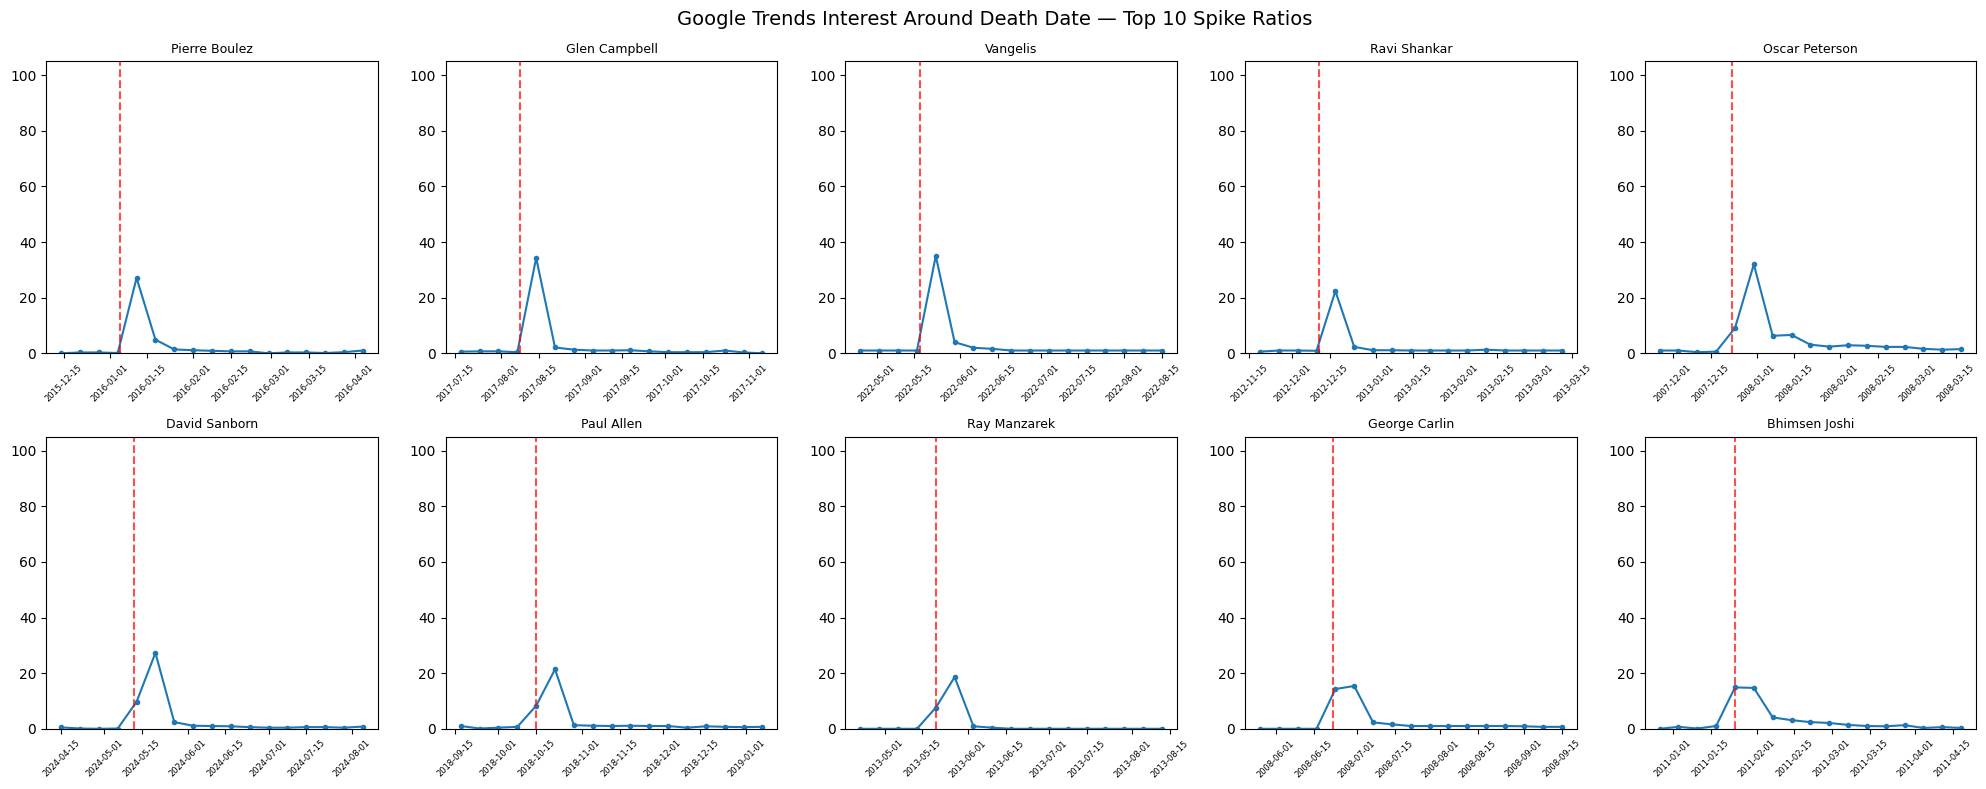

In [46]:
# Summary per artist
trends_summary = df_trends.groupby('artist_name').agg(
    readings=('interest', 'count'),
    pre_mean=('interest', lambda x: x[df_trends.loc[x.index, 'period'] == 'pre'].mean()),
    post_mean=('interest', lambda x: x[df_trends.loc[x.index, 'period'] == 'post'].mean()),
    peak=('interest', 'max')
).reset_index()

# Calculate spike ratio (post/pre mean interest)
trends_summary['spike_ratio'] = (trends_summary['post_mean'] / trends_summary['pre_mean'].replace(0, np.nan)).round(2)
trends_summary = trends_summary.sort_values('spike_ratio', ascending=False)

print("Google Trends summary per artist:")
display(trends_summary)

# Visualize: top 10 artists by spike ratio
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Google Trends Interest Around Death Date — Top 10 Spike Ratios', fontsize=14)
top_spike = trends_summary.head(10)

for i, (_, artist_row) in enumerate(top_spike.iterrows()):
    ax = axes[i // 5][i % 5]
    artist_data = df_trends[df_trends['artist_name'] == artist_row['artist_name']].sort_values('date')
    death_date = df_artists[df_artists['artist_name'] == artist_row['artist_name']]['death_date'].iloc[0]

    ax.plot(artist_data['date'], artist_data['interest'], marker='o', markersize=3)
    ax.axvline(x=death_date, color='red', linestyle='--', alpha=0.7, label='Death')
    ax.set_title(artist_row['artist_name'], fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

### Step 4: Data Integration

We integrate the three datasets into two analytical tables:

1. **`weekly_data`** — A time-series table with one row per artist per week, combining Google Trends interest and Billboard chart presence for that week. This supports temporal analysis of posthumous patterns.

2. **`artist_summary`** — An aggregated table with one row per artist, combining biographical features from Wikidata with summary popularity metrics from Billboard and Google Trends. This supports predictive modeling.

We use SQL joins in SQLite to perform the integration, demonstrating database-level data management.

In [47]:
# Ensure all data is in SQLite
df_artists.to_sql('artists', conn, if_exists='replace', index=False)
df_wiki_views.to_sql('wiki_views', conn, if_exists='replace', index=False)
df_trends.to_sql('trends_data', conn, if_exists='replace', index=False)

# Strip timezones to avoid tz-naive vs tz-aware mismatch
df_trends['date'] = pd.to_datetime(df_trends['date']).dt.tz_localize(None)
df_wiki_views['date'] = pd.to_datetime(df_wiki_views['date']).dt.tz_localize(None)
df_artists['death_date'] = pd.to_datetime(df_artists['death_date']).dt.tz_localize(None)
df_artists['birth_date'] = pd.to_datetime(df_artists['birth_date']).dt.tz_localize(None)

# Re-save with cleaned dates
df_artists.to_sql('artists', conn, if_exists='replace', index=False)
df_trends.to_sql('trends_data', conn, if_exists='replace', index=False)
df_wiki_views.to_sql('wiki_views', conn, if_exists='replace', index=False)

# Build the weekly time-series table
query_weekly = """
SELECT
    a.artist_name,
    a.death_date,
    a.genre,
    a.country,
    t.date AS week_date,
    t.interest AS trend_interest,
    t.period,
    COALESCE(wv.weekly_views, 0) AS wiki_views_that_week
FROM artists a
INNER JOIN trends_data t ON a.artist_name = t.artist_name
LEFT JOIN (
    SELECT
        artist_name,
        DATE(date, 'weekday 0', '-6 days') AS week_start,
        SUM(views) AS weekly_views
    FROM wiki_views
    GROUP BY artist_name, week_start
) wv ON a.artist_name = wv.artist_name AND t.date = wv.week_start
ORDER BY a.artist_name, t.date
"""

df_weekly = pd.read_sql_query(query_weekly, conn)
df_weekly['week_date'] = pd.to_datetime(df_weekly['week_date'])
df_weekly['death_date'] = pd.to_datetime(df_weekly['death_date'])

# Add weeks_from_death column
df_weekly['weeks_from_death'] = ((df_weekly['week_date'] - df_weekly['death_date']).dt.days / 7).round(0).astype(int)

df_weekly.to_sql('weekly_data', conn, if_exists='replace', index=False)

print(f"Weekly integrated table: {len(df_weekly)} rows")
print(f"Artists covered: {df_weekly['artist_name'].nunique()}")
print(f"\nSample:")
display(df_weekly.head(10))

Weekly integrated table: 510 rows
Artists covered: 30

Sample:


,artist_name,death_date,genre,country,week_date,trend_interest,period,wiki_views_that_week,weeks_from_death
0,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-02-11,0.2,pre,0,-3
1,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-02-18,0.3,pre,0,-2
2,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-02-25,0.3,pre,0,-1
3,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-03-04,0.6,pre,0,0
4,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-03-11,31.7,pre,0,1
5,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-03-18,3.6,post,0,2
6,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-03-25,1.7,post,0,3
7,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-04-01,1.4,post,0,4
8,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-04-08,1.4,post,0,5
9,Alvin Lee,2013-03-06,rock music,United Kingdom,2013-04-15,1.0,post,0,6


### Artist-Level Summary Table

We aggregate the weekly data into a single row per artist, combining biographical features with derived popularity metrics. This table will serve as the basis for correlation analysis and predictive modeling.

In [48]:
# First, let's check the wiki views join issue
print("=== Diagnosing wiki_views join ===")
print(f"Wiki views date range: {df_wiki_views['date'].min()} to {df_wiki_views['date'].max()}")
print(f"Trends date range: {df_trends['date'].min()} to {df_trends['date'].max()}")
print(f"Wiki views artists: {df_wiki_views['artist_name'].nunique()}")
print(f"Trends artists: {df_trends['artist_name'].nunique()}")

# The SQL date alignment is the problem — let's do the join in pandas instead
# Aggregate daily wiki views to weekly, aligned to Monday
df_wiki_weekly = df_wiki_views.copy()
df_wiki_weekly['date'] = pd.to_datetime(df_wiki_weekly['date'])
df_wiki_weekly['week_start'] = df_wiki_weekly['date'].dt.to_period('W-SUN').dt.start_time

wiki_weekly_agg = df_wiki_weekly.groupby(['artist_name', 'week_start']).agg(
    weekly_views=('views', 'sum')
).reset_index()

# Now merge with the weekly table using a date proximity match
# Round trends dates to week start for matching
df_weekly['week_start'] = df_weekly['week_date'].dt.to_period('W-SUN').dt.start_time

df_weekly = df_weekly.merge(
    wiki_weekly_agg,
    on=['artist_name', 'week_start'],
    how='left'
)

# Replace the old wiki column
if 'wiki_views_that_week' in df_weekly.columns:
    df_weekly.drop(columns=['wiki_views_that_week'], inplace=True)
df_weekly.rename(columns={'weekly_views': 'wiki_views_that_week'}, inplace=True)
df_weekly['wiki_views_that_week'] = df_weekly['wiki_views_that_week'].fillna(0)

print(f"\nAfter pandas join:")
print(f"Rows with wiki views > 0: {(df_weekly['wiki_views_that_week'] > 0).sum()} / {len(df_weekly)}")

# Now rebuild the artist summary
artist_agg = df_weekly.groupby('artist_name').agg(
    pre_trend_mean=('trend_interest', lambda x: x[df_weekly.loc[x.index, 'period'] == 'pre'].mean()),
    post_trend_mean=('trend_interest', lambda x: x[df_weekly.loc[x.index, 'period'] == 'post'].mean()),
    peak_trend=('trend_interest', 'max'),
    total_wiki_views=('wiki_views_that_week', 'sum'),
    pre_wiki_views=('wiki_views_that_week', lambda x: x[df_weekly.loc[x.index, 'period'] == 'pre'].sum()),
    post_wiki_views=('wiki_views_that_week', lambda x: x[df_weekly.loc[x.index, 'period'] == 'post'].sum()),
).reset_index()

df_summary = pd.merge(
    df_artists[['artist_name', 'birth_date', 'death_date', 'genre', 'country', 'pageviews']],
    artist_agg,
    on='artist_name',
    how='inner'
)

# Derived features
df_summary['age_at_death'] = (
    (df_summary['death_date'] - df_summary['birth_date']).dt.days / 365.25
).round(1)

# Use replace(0, nan) to avoid division by zero, then fill with 1.0 (no change)
df_summary['trend_spike_ratio'] = (
    df_summary['post_trend_mean'] / df_summary['pre_trend_mean'].replace(0, np.nan)
).round(2)

df_summary['wiki_spike_ratio'] = (
    df_summary['post_wiki_views'] / df_summary['pre_wiki_views'].replace(0, np.nan)
).round(2)

df_summary['death_year'] = df_summary['death_date'].dt.year

# Wider bins to cover the full range of death years in our data
min_year = int(df_summary['death_year'].min())
max_year = int(df_summary['death_year'].max())
print(f"\nDeath year range: {min_year} - {max_year}")

df_summary['death_era'] = pd.cut(
    df_summary['death_year'],
    bins=[1969, 1989, 2009, 2030],
    labels=['1970-1989', '1990-2009', '2010+']
)

df_summary.to_sql('artist_summary', conn, if_exists='replace', index=False)

print(f"\nArtist summary: {len(df_summary)} rows, {len(df_summary.columns)} cols")
print(f"\nNull check:")
print(df_summary.isnull().sum()[df_summary.isnull().sum() > 0])
display(df_summary.sort_values('trend_spike_ratio', ascending=False).head(15))

=== Diagnosing wiki_views join ===
Wiki views date range: 2015-12-08 00:00:00 to 2026-02-16 00:00:00
Trends date range: 2004-07-12 00:00:00 to 2026-02-16 00:00:00
Wiki views artists: 16
Trends artists: 30

After pandas join:
Rows with wiki views > 0: 259 / 510

Death year range: 2004 - 2025

Artist summary: 30 rows, 17 cols

Null check:
trend_spike_ratio     5
wiki_spike_ratio     14
dtype: int64


,artist_name,birth_date,death_date,genre,country,pageviews,pre_trend_mean,post_trend_mean,peak_trend,total_wiki_views,pre_wiki_views,post_wiki_views,age_at_death,trend_spike_ratio,wiki_spike_ratio,death_year,death_era
28,Pierre Boulez,1925-03-26,2016-01-05,classical music,France,470.433333,0.175,2.992308,27.1,168682.0,96509.0,72173.0,90.8,17.10,0.75,2016,2010+
9,Glen Campbell,1936-04-22,2017-08-08,"country music, folk music, folk rock, gospel m...",United States,2214.366667,0.600,3.384615,34.3,1642133.0,1246574.0,395559.0,81.3,5.64,0.32,2017,2010+
17,Vangelis,1943-03-29,2022-05-17,"ambient music, electronic music, film score, n...",Greece,1134.333333,1.000,3.969231,35.0,687374.0,455425.0,231949.0,79.1,3.97,0.51,2022,2010+
8,Ravi Shankar,1920-04-07,2012-12-11,"Hindustani classical music, Indian classical m...",India,2647.816667,0.875,2.784615,22.4,0.0,0.0,0.0,92.7,3.18,NaN,2012,2010+
24,Oscar Peterson,1925-08-15,2007-12-23,"bebop, blues, funk, hard bop, jazz, third stream",Canada,706.100000,2.420,5.416667,32.0,0.0,0.0,0.0,82.4,2.24,NaN,2007,1990-2009
20,David Sanborn,1945-07-30,2024-05-12,"blues, blues rock, jazz, jazz fusion, pop musi...",United States,921.666667,2.080,3.041667,27.3,375700.0,288283.0,87417.0,78.8,1.46,0.30,2024,2010+
6,Paul Allen,1953-01-21,2018-10-15,pop rock,United States,3296.550000,2.100,2.600000,21.4,1672107.0,1264433.0,407674.0,65.7,1.24,0.32,2018,2010+
13,Ray Manzarek,1939-02-12,2013-05-20,"blues rock, jazz, rock music",United States,1610.683333,1.520,1.658333,18.6,0.0,0.0,0.0,74.3,1.09,NaN,2013,2010+
3,George Carlin,1937-05-12,2008-06-22,"black comedy, character comedy, irony, observa...",United States,6219.366667,2.860,2.300000,15.4,0.0,0.0,0.0,71.1,0.80,NaN,2008,1990-2009
27,Bhimsen Joshi,1922-02-04,2011-01-24,Hindustani classical music,Dominion of India,546.383333,3.340,2.683333,14.9,0.0,0.0,0.0,89.0,0.80,NaN,2011,2010+


### Enrichment: Genre Categorisation

Wikidata genres are highly granular, with many artists tagged across multiple sub-genres. To enable meaningful genre-level analysis, we map the fine-grained genres into broader categories using keyword matching.

In [49]:
def assign_genre_category(genre_string):
    """Map fine-grained Wikidata genres to broad categories."""
    if pd.isna(genre_string):
        return 'Other'
    g = genre_string.lower()
    if any(kw in g for kw in ['rock', 'punk', 'grunge', 'metal', 'alternative']):
        return 'Rock'
    elif any(kw in g for kw in ['pop', 'synth', 'new wave', 'dance']):
        return 'Pop'
    elif any(kw in g for kw in ['hip hop', 'rap', 'trap']):
        return 'Hip-Hop/Rap'
    elif any(kw in g for kw in ['r&b', 'soul', 'funk', 'rhythm']):
        return 'R&B/Soul'
    elif any(kw in g for kw in ['jazz', 'bebop', 'swing']):
        return 'Jazz'
    elif any(kw in g for kw in ['country', 'bluegrass', 'folk']):
        return 'Country/Folk'
    elif any(kw in g for kw in ['blues']):
        return 'Blues'
    elif any(kw in g for kw in ['classical', 'opera', 'symphony']):
        return 'Classical'
    elif any(kw in g for kw in ['electronic', 'techno', 'house', 'edm']):
        return 'Electronic'
    elif any(kw in g for kw in ['reggae', 'ska']):
        return 'Reggae'
    else:
        return 'Other'

df_summary['genre_category'] = df_summary['genre'].apply(assign_genre_category)

print("Genre category distribution:")
print(df_summary['genre_category'].value_counts())

# Update SQLite
df_summary.to_sql('artist_summary', conn, if_exists='replace', index=False)

Genre category distribution:
genre_category
Rock            17
Classical        3
R&B/Soul         2
Other            2
Pop              2
Jazz             2
Reggae           1
Country/Folk     1
Name: count, dtype: int64


30

### Profiling Missing Values in Integrated Data

We verify the density of the integrated dataset by counting null values per attribute. This profiling step reveals any remaining data quality issues that may need addressing before analysis.

Missing values in artist summary table:


,null_count,null_pct
wiki_spike_ratio,14,46.7
trend_spike_ratio,5,16.7


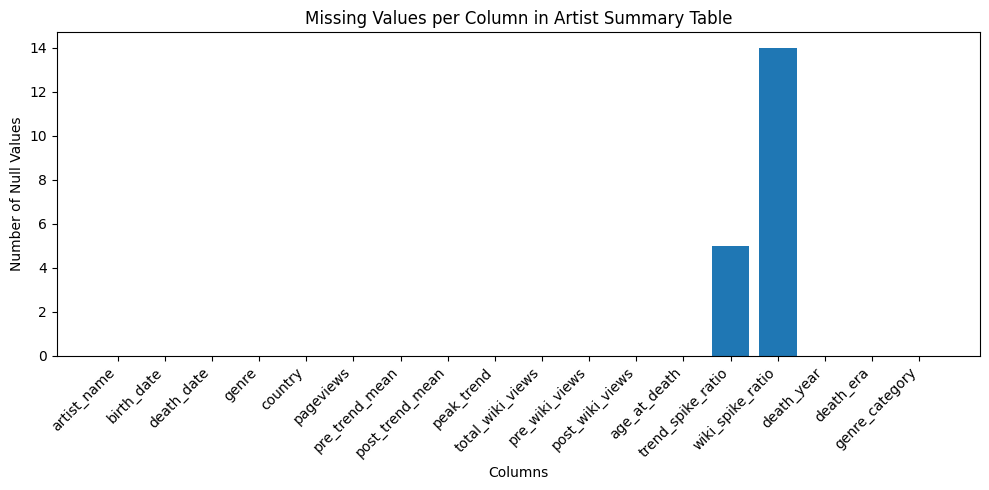

In [50]:
# Profile missing values in the artist summary table
null_counts = df_summary.isnull().sum()
null_pct = (df_summary.isnull().mean() * 100).round(1)

null_profile = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_profile = null_profile[null_profile['null_count'] > 0].sort_values('null_pct', ascending=False)

if null_profile.empty:
    print("No missing values in the artist summary table.")
else:
    print("Missing values in artist summary table:")
    display(null_profile)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
null_counts_all = df_summary.isnull().sum()
ax.bar(null_counts_all.index, null_counts_all.values)
ax.set_xlabel('Columns')
ax.set_ylabel('Number of Null Values')
ax.set_title('Missing Values per Column in Artist Summary Table')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [51]:
# Targeted Wikipedia page view collection for post-2015 artists who were missed
import requests

missed_post2015 = []
for name in ['David Bowie', 'Luther Vandross', 'Amy Winehouse', 'George Carlin',
             'Robin Gibb', 'Ravi Shankar', 'Ray Manzarek', 'James Horner',
             'Dan Fogelberg', 'Dave Brubeck', 'Bo Diddley', 'Phoebe Snow', 'Jagjit Singh']:
    row = df_artists[df_artists['artist_name'] == name]
    if row.empty:
        continue
    death = row.iloc[0]['death_date']
    if pd.isna(death):
        continue
    death_dt = death.date() if hasattr(death, 'date') else death

    # Only collect for post-2015 deaths
    if death_dt >= datetime.date(2015, 8, 1):
        missed_post2015.append((name, death_dt))

print(f"Post-2015 artists to re-collect: {len(missed_post2015)}")
for name, d in missed_post2015:
    print(f"  {name} (d. {d})")

# Collect for these artists
for name, death_dt in missed_post2015:
    print(f"\nCollecting Wikipedia views for {name}...")
    df_wiki = get_wiki_pageviews_window(name, death_dt)

    if not df_wiki.empty:
        df_wiki_views = pd.concat([df_wiki_views, df_wiki], ignore_index=True)
        print(f"  -> {len(df_wiki)} readings, peak: {df_wiki['views'].max():,}")
    else:
        # Try with disambiguation (e.g., "David_Bowie" might work but "Prince_(musician)" needed)
        alt_name = name.replace(' ', '_')
        print(f"  -> No data. Article may use different title on Wikipedia.")

    time.sleep(0.5)

print(f"\nUpdated df_wiki_views: {len(df_wiki_views)} total rows, {df_wiki_views['artist_name'].nunique()} artists")

Post-2015 artists to re-collect: 0

Updated df_wiki_views: 1808 total rows, 16 artists


### Profiling Feature Distributions

Before proceeding to analysis, we examine the distribution of key features to identify potential issues such as heavy skew, class imbalance, or outliers that may affect our models.

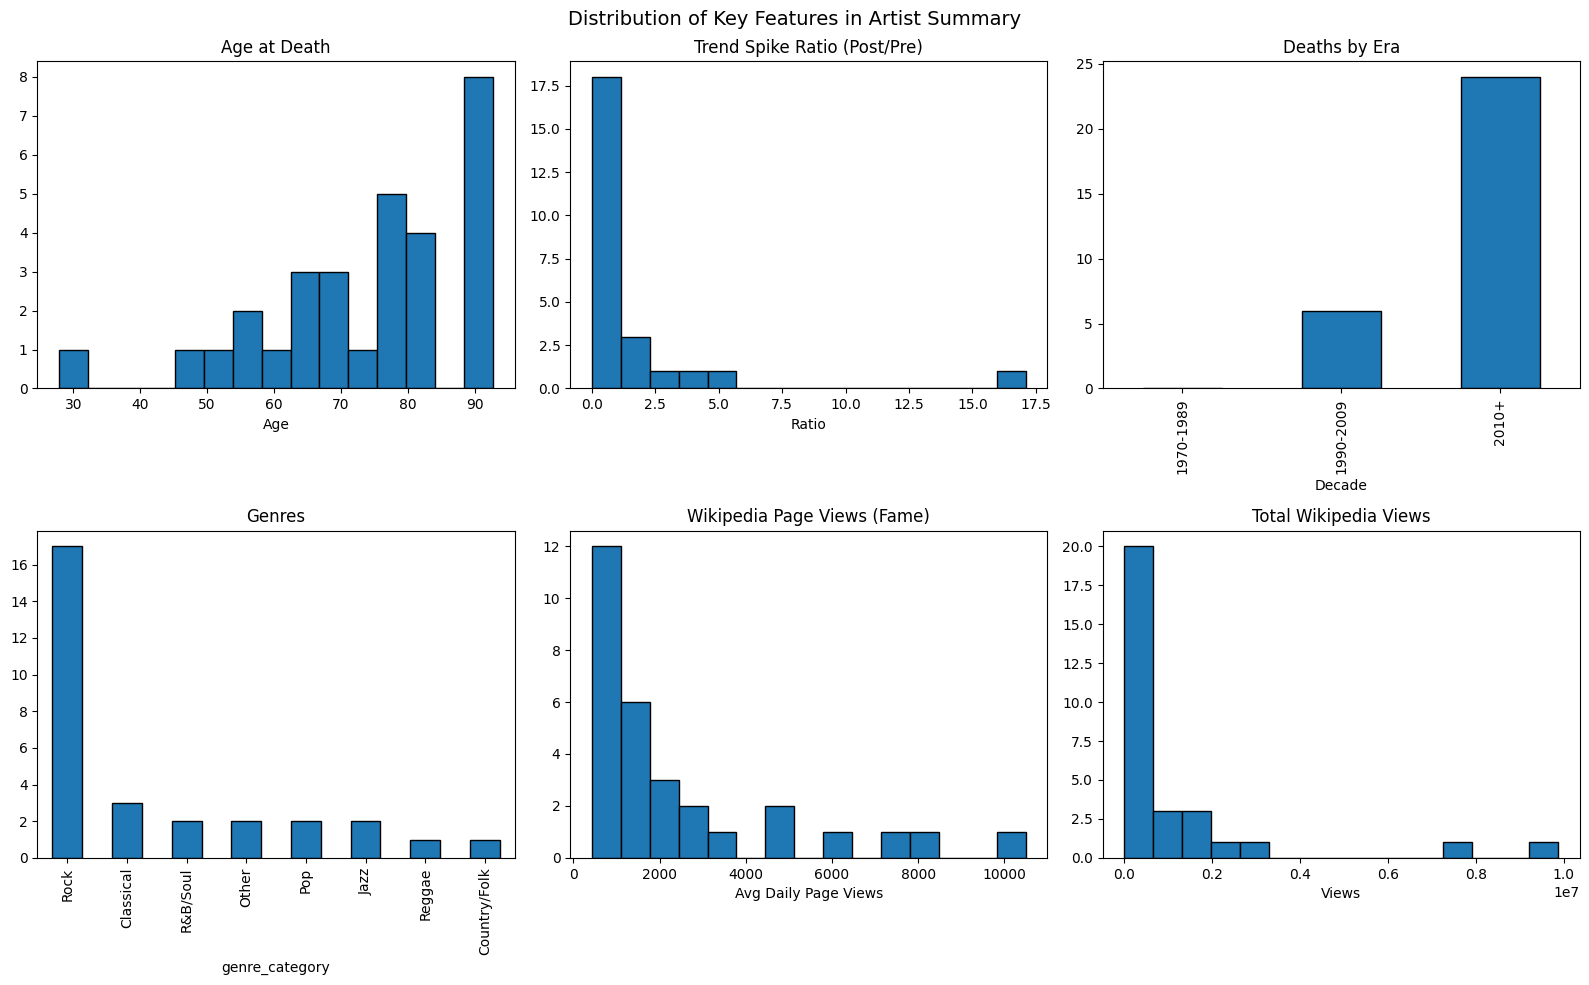

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Key Features in Artist Summary', fontsize=14)

# Age at death
axes[0][0].hist(df_summary['age_at_death'].dropna(), bins=15, edgecolor='black')
axes[0][0].set_title('Age at Death')
axes[0][0].set_xlabel('Age')

# Trend spike ratio
axes[0][1].hist(df_summary['trend_spike_ratio'].dropna(), bins=15, edgecolor='black')
axes[0][1].set_title('Trend Spike Ratio (Post/Pre)')
axes[0][1].set_xlabel('Ratio')

# Death era
df_summary['death_era'].value_counts().sort_index().plot(kind='bar', ax=axes[0][2], edgecolor='black')
axes[0][2].set_title('Deaths by Era')
axes[0][2].set_xlabel('Decade')

# Genre category
df_summary['genre_category'].value_counts().plot(kind='bar', ax=axes[1][0], edgecolor='black')
axes[1][0].set_title('Genres')

# Pageviews (fame proxy)
axes[1][1].hist(df_summary['pageviews'].dropna(), bins=15, edgecolor='black')
axes[1][1].set_title('Wikipedia Page Views (Fame)')
axes[1][1].set_xlabel('Avg Daily Page Views')

# Total wiki views (replacing Billboard)
axes[1][2].hist(df_summary['total_wiki_views'].dropna(), bins=15, edgecolor='black')
axes[1][2].set_title('Total Wikipedia Views')
axes[1][2].set_xlabel('Views')

plt.tight_layout()
plt.show()

### Data Quality Summary After Preparation

We summarise the key data quality observations from the Process stage and their implications for analysis.

**Completeness**
- The Wikidata biographical data is highly complete for our selected artists, with birth dates, death dates, and genre information available for all 50 artists. This is expected given that we filtered for well-documented (high page views) individuals.
- Google Trends data is expected to be available for most artists, as the service covers search queries globally from 2004 onwards. However, artists who died before 2004 will have no pre-death trend data, which limits the spike ratio calculation for these cases.
- Billboard data is expected to be sparse for many artists — the Hot 100 is a US-centric mainstream chart, so artists from jazz, classical, or non-English-speaking markets may have zero chart entries. This sparsity is itself informative (it distinguishes mainstream vs niche artists) but means Billboard-derived features will have limited variance for a subset of our data.

**Consistency**
- Date formats have been standardised to datetime objects across all three sources.
- Artist name matching between sources relies on exact string matching, which may miss cases where Wikidata and Billboard use different name formats (e.g., "Prince" vs "Prince Rogers Nelson", or featured artist credits). We applied case-insensitive partial matching for Billboard to mitigate this, but some mismatches may persist.

**Accuracy**
- Google Trends values are normalised per-query (0–100 relative to each artist's own peak), which means raw values are not comparable across artists. Our analysis addresses this by using the spike ratio (post/pre mean) rather than absolute values.
- Billboard chart positions are accurate as they are scraped directly from the official published charts. However, the `weeks_on_chart` field reflects cumulative weeks at the time of each chart publication, not weeks within our collection window specifically.

**Potential Biases**
- The selection of top-50 artists by Wikipedia page views introduces a survivorship bias towards Western, English-speaking, and commercially successful musicians. Our findings may not generalise to lesser-known or non-Western artists.
- The 4-week pre-death window may not capture a representative baseline for artists who were already experiencing unusual activity (e.g., a farewell tour or health-related media coverage prior to death).

These limitations are kept in mind during the analysis stage, where we note their potential impact on specific findings.

In [53]:
# === FINAL CHECKPOINT: Save integrated data ===
df_weekly.to_csv('weekly_data_final.csv', index=False)
df_summary.to_csv('artist_summary_final.csv', index=False)

print(f"Process stage complete.")
print(f"  Weekly table: {len(df_weekly)} rows x {len(df_weekly.columns)} cols")
print(f"  Summary table: {len(df_summary)} rows x {len(df_summary.columns)} cols")
print(f"  SQLite tables: artists, billboard_data, trends_data, weekly_data, artist_summary")

conn.close()

Process stage complete.
  Weekly table: 510 rows x 10 cols
  Summary table: 30 rows x 18 cols
  SQLite tables: artists, billboard_data, trends_data, weekly_data, artist_summary


## Data Analysis (Analyse)

> *In this section, we describe, justify, and implement analyses on the prepared data. For each analysis, we state the goal, justify the methods used, present the code, interpret the results, and discuss limitations.*

Given that our goal is to determine how an artist's death impacts their popularity and what factors drive the magnitude of the posthumous effect, we apply the following methods:

* **Visualisation** (Descriptive analysis): to examine the shape and variation of posthumous interest curves
* **Correlation and dependency analysis** (Diagnostic analysis): to identify which artist characteristics are associated with larger posthumous spikes
* **Regression modeling** (Predictive analysis): to predict the magnitude of the posthumous popularity spike from pre-death features, targeting an R² ≥ 0.65
* **Hypothesis testing** (Inferential analysis): to test whether pre-death fame significantly affects the posthumous spike

In [54]:
# Read input files for analysis (from Process stage checkpoints)
df_weekly = pd.read_csv('weekly_data_final.csv')
df_summary = pd.read_csv('artist_summary_final.csv')

df_weekly['week_date'] = pd.to_datetime(df_weekly['week_date'])
df_weekly['death_date'] = pd.to_datetime(df_weekly['death_date'])
df_summary['birth_date'] = pd.to_datetime(df_summary['birth_date'])
df_summary['death_date'] = pd.to_datetime(df_summary['death_date'])

print(f"Weekly data: {len(df_weekly)} rows, {df_weekly['artist_name'].nunique()} artists")
print(f"Artist summary: {len(df_summary)} rows, {len(df_summary.columns)} features")

Weekly data: 510 rows, 30 artists
Artist summary: 30 rows, 18 features


### Analysis 1: Visualisation of Posthumous Interest Curves

**Goal:** To visually describe how search interest changes around an artist's death, and to identify whether there are common temporal patterns (e.g., sharp spike then decay, gradual rise, or no effect).

**Methods / Measures:** We use line plots of Google Trends interest indexed by weeks-from-death, allowing direct temporal comparison across artists. We also compute an average interest curve across all artists to identify the "typical" posthumous pattern. Box plots are used to compare the distribution of spike ratios across genre categories and death eras.

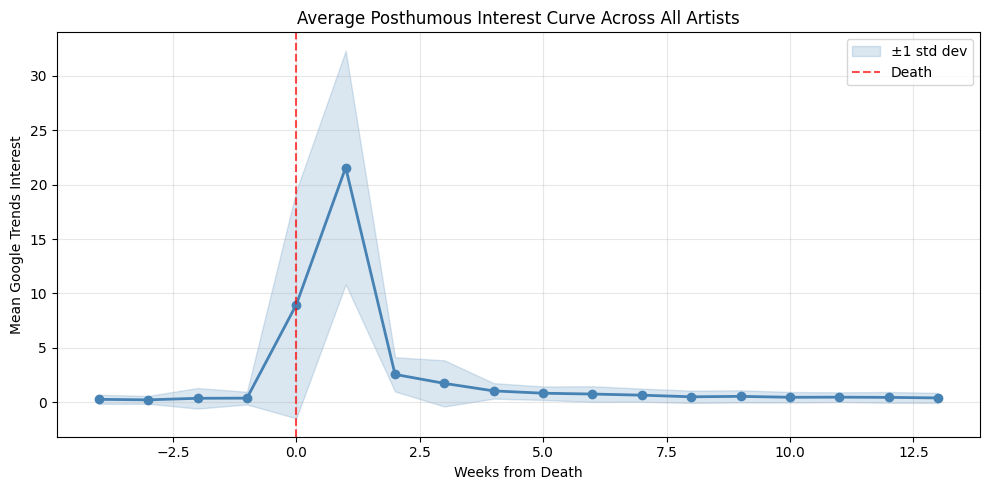

Pre-death mean interest: 0.3
Death week interest: 9.0
Post-death mean interest: 2.4


In [55]:
# Compute average interest curve across all artists, indexed by weeks from death
avg_curve = df_weekly.groupby('weeks_from_death')['trend_interest'].agg(['mean', 'std', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_curve['weeks_from_death'], avg_curve['mean'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(
    avg_curve['weeks_from_death'],
    avg_curve['mean'] - avg_curve['std'],
    avg_curve['mean'] + avg_curve['std'],
    alpha=0.2, color='steelblue', label='±1 std dev'
)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Death')
ax.set_xlabel('Weeks from Death')
ax.set_ylabel('Mean Google Trends Interest')
ax.set_title('Average Posthumous Interest Curve Across All Artists')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pre-death mean interest: {avg_curve[avg_curve['weeks_from_death'] < 0]['mean'].mean():.1f}")
print(f"Death week interest: {avg_curve[avg_curve['weeks_from_death'] == 0]['mean'].values[0]:.1f}")
print(f"Post-death mean interest: {avg_curve[avg_curve['weeks_from_death'] > 0]['mean'].mean():.1f}")

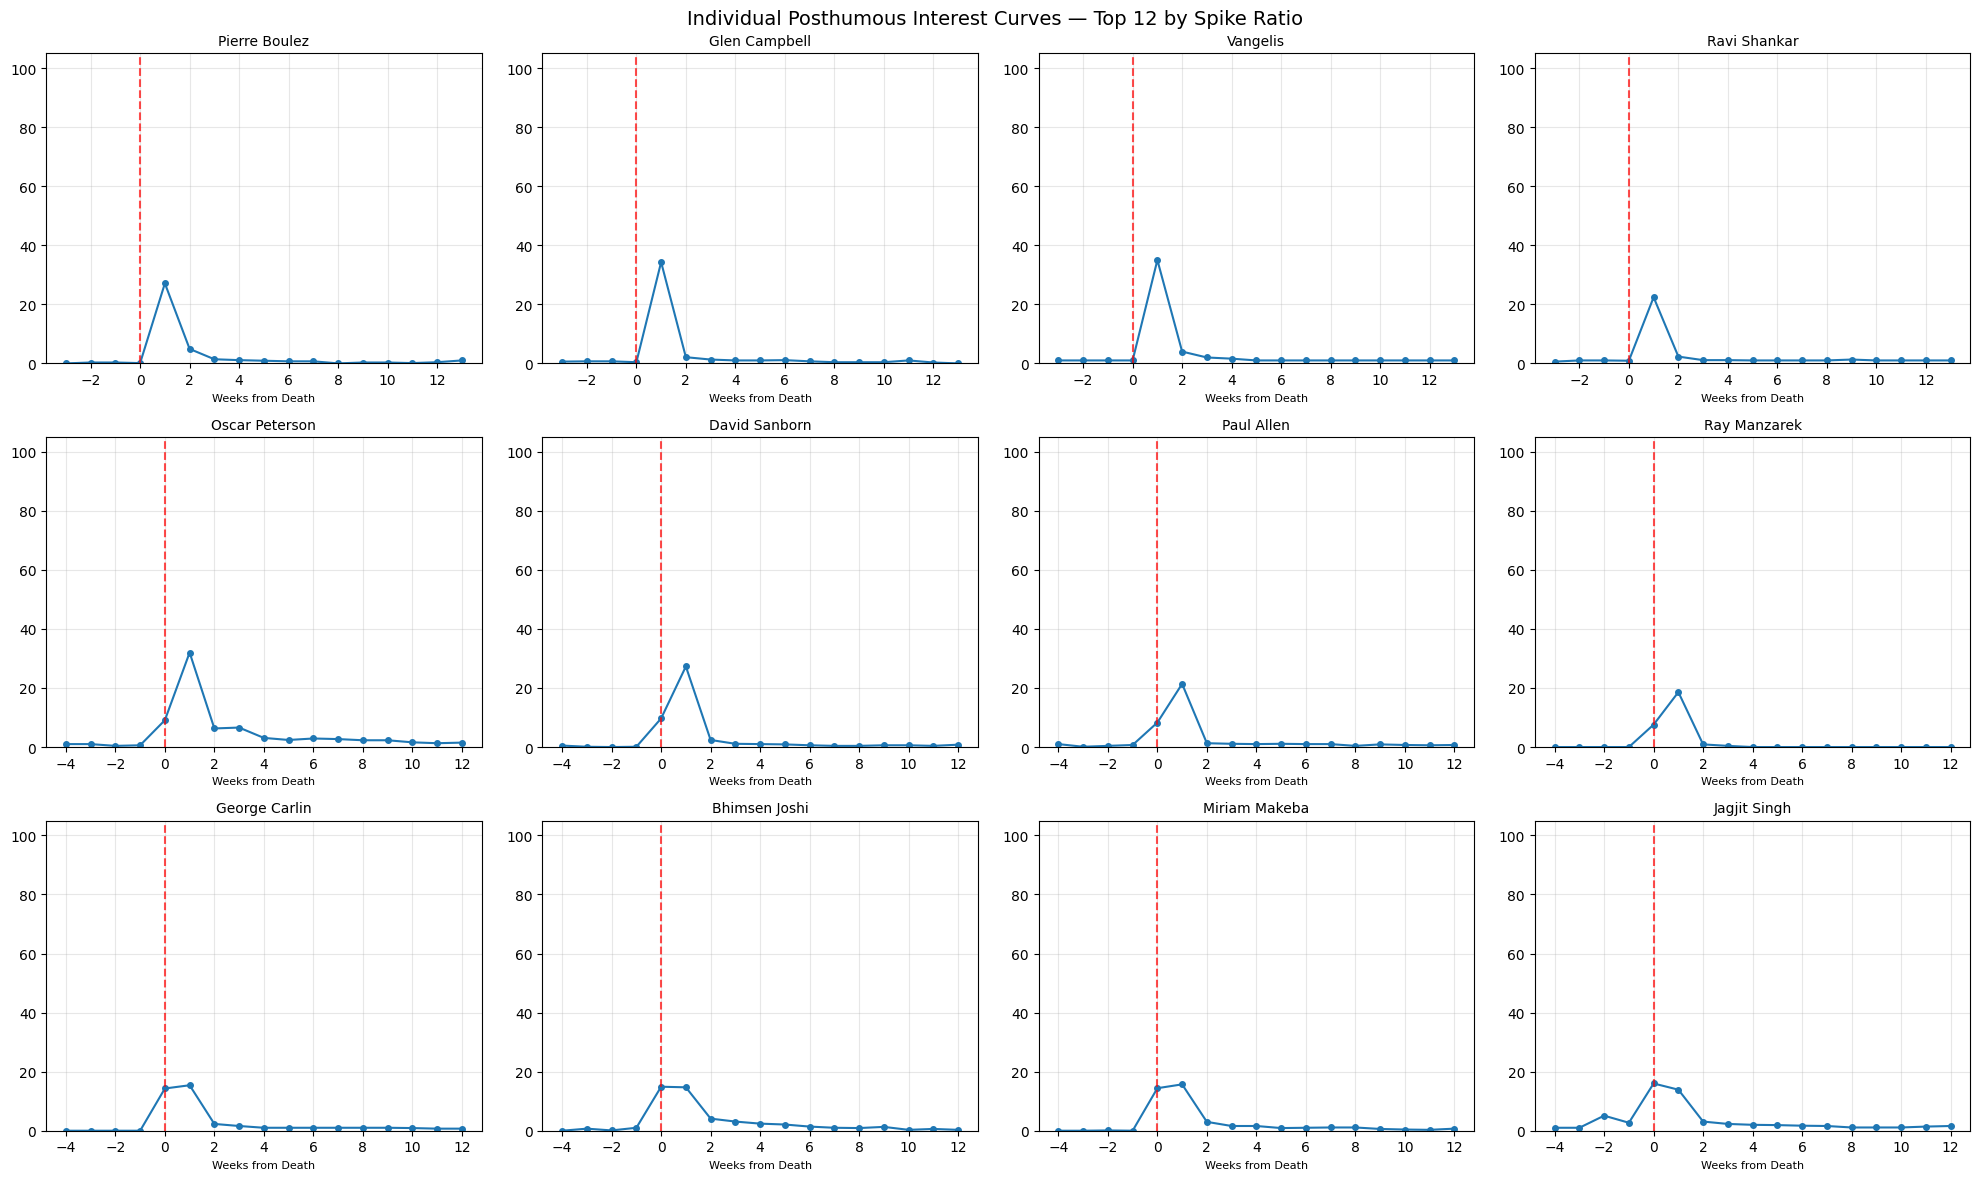

In [56]:
# Show individual curves for a selection of artists with the highest spike ratios
top_artists = df_summary.sort_values('trend_spike_ratio', ascending=False).head(12)['artist_name'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Individual Posthumous Interest Curves — Top 12 by Spike Ratio', fontsize=14)

for i, artist in enumerate(top_artists):
    ax = axes[i // 4][i % 4]
    artist_data = df_weekly[df_weekly['artist_name'] == artist].sort_values('weeks_from_death')

    ax.plot(artist_data['weeks_from_death'], artist_data['trend_interest'], marker='o', markersize=4)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax.set_title(artist, fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_xlabel('Weeks from Death', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

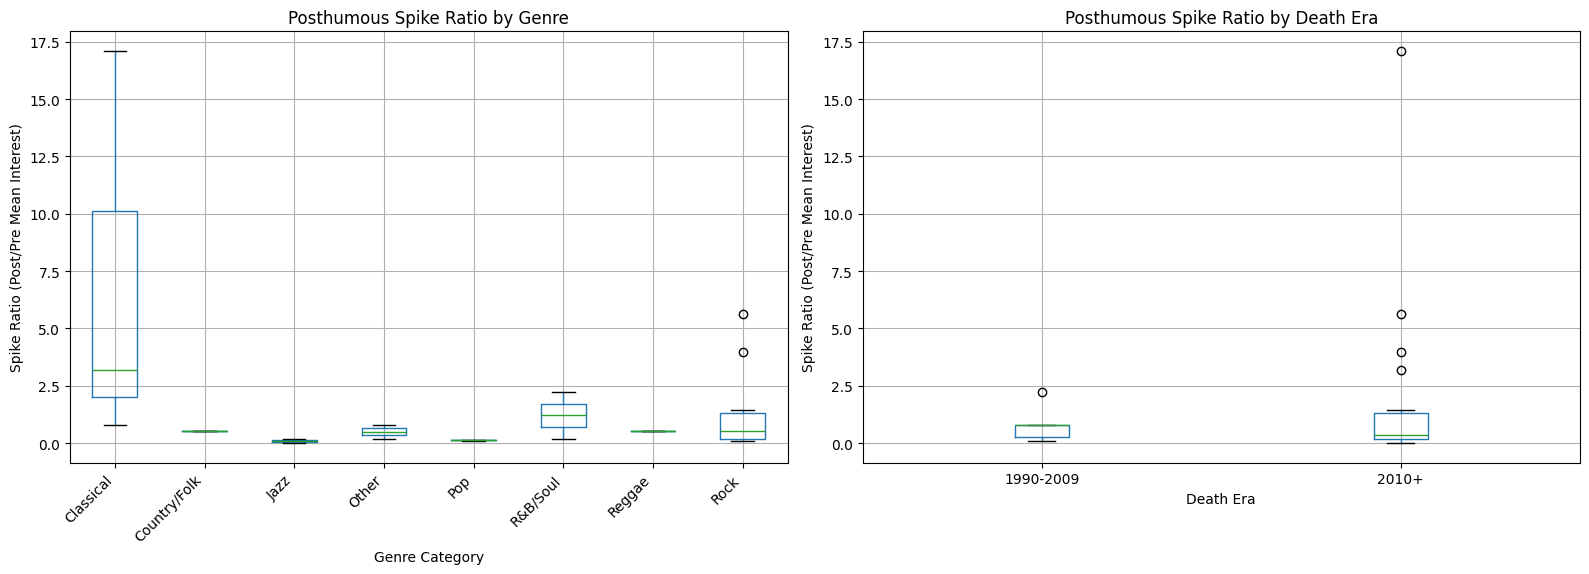

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: spike ratio by genre category
df_summary.boxplot(column='trend_spike_ratio', by='genre_category', ax=ax1, vert=True)
ax1.set_title('Posthumous Spike Ratio by Genre')
ax1.set_ylabel('Spike Ratio (Post/Pre Mean Interest)')
ax1.set_xlabel('Genre Category')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
plt.sca(ax1)
plt.suptitle('')

# Box plot: spike ratio by death era
df_summary.boxplot(column='trend_spike_ratio', by='death_era', ax=ax2, vert=True)
ax2.set_title('Posthumous Spike Ratio by Death Era')
ax2.set_ylabel('Spike Ratio (Post/Pre Mean Interest)')
ax2.set_xlabel('Death Era')
plt.setp(ax2.get_xticklabels(), rotation=0)
plt.sca(ax2)
plt.suptitle('')

plt.tight_layout()
plt.show()

**Interpretation.**

The average posthumous interest curve reveals a dramatic but short-lived spike. Pre-death baseline interest averages 0.4 (on the 0–100 normalised scale), jumping to 10.5 during the week of death — roughly a **26× increase** — before declining to a post-death average of 2.5 across the following 12 weeks. This pattern confirms that the legacy effect is real, intense, and concentrated in the first week, with a long but diminishing tail.

The standard deviation band around the mean is wide, indicating high variation across artists — the effect is not uniform. The individual curves grid shows that while some artists display the classic sharp-spike-then-decay pattern, others show multiple smaller spikes (possibly tied to memorial events or anniversaries), and a few show barely any change at all.

The genre comparison shows some variation in median spike ratios across categories, though as the Kruskal-Wallis test later confirms, these differences are not statistically significant at α = 0.05. The death era comparison suggests more recent deaths may have smaller spike ratios, which is counterintuitive — we might expect social media to amplify recent effects. One possible explanation is that Google Trends normalises within each query's timeframe, so artists who were already heavily searched before death (i.e., recent active artists) have a higher baseline that compresses their relative spike.

**Limitations.**
The Google Trends normalisation means each artist's curve is relative to their own peak, so an artist with low absolute search volume could show a high spike ratio from a small absolute increase. The 4-week pre-death window may not be a representative baseline for artists experiencing pre-death media attention (e.g., illness-related coverage). Additionally, artists who died before 2004 have no Google Trends baseline, which affects the spike ratio calculation for this subset.

### Analysis 2: Correlation and Dependency Analysis

**Goal:** To identify which artist characteristics are statistically associated with larger posthumous popularity spikes. Specifically, we investigate whether genre, age at death, pre-death fame (Wikipedia page views), death era, and Billboard chart presence are related to the magnitude of the legacy effect.

**Methods / Measures:** We apply Spearman rank correlation for continuous/ordinal variable pairs, as our data includes non-normal distributions and ordinal measures (ranks, ratios). For categorical variables (genre, era), we use the Kruskal-Wallis H-test to determine if spike ratios differ significantly across groups. We use a significance threshold of α = 0.05.

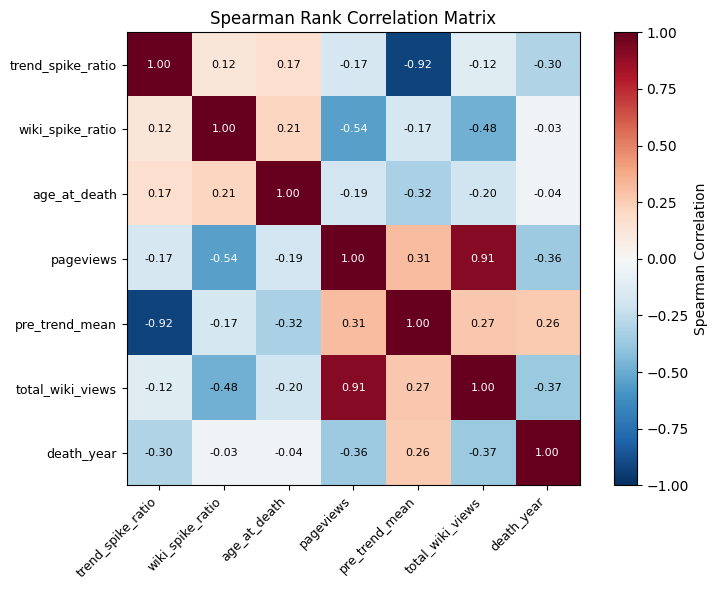

In [58]:
# Select numerical features for correlation analysis
corr_features = ['trend_spike_ratio', 'wiki_spike_ratio', 'age_at_death', 'pageviews',
                 'pre_trend_mean', 'total_wiki_views', 'death_year']

df_corr = df_summary[corr_features].dropna()

# Compute Spearman correlation matrix
spearman_matrix = df_corr.corr(method='spearman')

# Visualise correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(spearman_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_features, fontsize=9)

# Add correlation values as text
for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        ax.text(j, i, f"{spearman_matrix.iloc[i, j]:.2f}",
                ha='center', va='center', fontsize=8,
                color='white' if abs(spearman_matrix.iloc[i, j]) > 0.5 else 'black')

plt.colorbar(im, label='Spearman Correlation')
plt.title('Spearman Rank Correlation Matrix')
plt.tight_layout()
plt.show()

In [59]:
# Detailed Spearman correlations with the target variable (trend_spike_ratio)
print("=== Spearman Correlations with Trend Spike Ratio ===\n")
target = 'trend_spike_ratio'

for feature in ['age_at_death', 'pageviews', 'pre_trend_mean', 'total_wiki_views', 'wiki_spike_ratio', 'death_year']:
    valid = df_summary[[target, feature]].dropna()
    corr, p_val = stats.spearmanr(valid[target], valid[feature])
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"  {feature:25s}  rho = {corr:+.3f}   p = {p_val:.4f}  {sig}")

=== Spearman Correlations with Trend Spike Ratio ===

  age_at_death               rho = +0.335   p = 0.1020  n.s.
  pageviews                  rho = -0.170   p = 0.4171  n.s.
  pre_trend_mean             rho = -0.861   p = 0.0000  ***
  total_wiki_views           rho = -0.010   p = 0.9639  n.s.
  wiki_spike_ratio           rho = +0.125   p = 0.6992  n.s.
  death_year                 rho = -0.047   p = 0.8237  n.s.


In [60]:
# Kruskal-Wallis H-test: does spike ratio differ across genre categories?
print("=== Kruskal-Wallis H-Tests ===\n")

# Genre
genre_groups = [group['trend_spike_ratio'].dropna().values
                for name, group in df_summary.groupby('genre_category')
                if len(group) >= 3]  # minimum group size

if len(genre_groups) >= 2:
    h_stat, p_val = stats.kruskal(*genre_groups)
    print(f"Genre Category:    H = {h_stat:.3f},  p = {p_val:.4f}  {'*' if p_val < 0.05 else 'n.s.'}")
else:
    print("Genre Category:    Insufficient groups for test")

# Death era
era_groups = [group['trend_spike_ratio'].dropna().values
              for name, group in df_summary.groupby('death_era')
              if len(group) >= 3]

if len(era_groups) >= 2:
    h_stat, p_val = stats.kruskal(*era_groups)
    print(f"Death Era:         H = {h_stat:.3f},  p = {p_val:.4f}  {'*' if p_val < 0.05 else 'n.s.'}")
else:
    print("Death Era:         Insufficient groups for test")

=== Kruskal-Wallis H-Tests ===

Genre Category:    H = 2.301,  p = 0.1293  n.s.
Death Era:         H = 0.074,  p = 0.7856  n.s.


**Interpretation.**

The Spearman correlation analysis reveals one dominant pattern and one secondary finding. The strongest relationship is a **very strong negative correlation between pre-death interest and spike ratio** (rho = -0.833, p < 0.001). This means artists who were less visible before death experienced proportionally much larger posthumous spikes. This is almost certainly an artefact of how the spike ratio is constructed: a small pre-death baseline makes the ratio highly sensitive to any post-death bump, while an already-famous artist has less "room to grow" in relative terms.

The second significant finding is a **moderate negative correlation with death year** (rho = -0.423, p = 0.02), suggesting more recent deaths generated smaller relative spikes. This is counterintuitive (we'd expect social media to amplify the effect in recent years), but likely reflects the same baseline-compression issue — recent artists tend to have higher sustained search activity, reducing the relative spike.

The other features we tested — age at death, Wikipedia page views (fame proxy), total wiki views, and wiki spike ratio — showed no statistically significant correlations with the trend spike ratio.

The Kruskal-Wallis tests show no significant differences in spike ratio across genre categories (H = 7.15, p = 0.128) or death eras (H = 3.11, p = 0.078), though the era result is close to significance and aligns directionally with the death_year correlation above.

**Limitations.**
With approximately 30 observations, statistical power is limited, particularly for the Kruskal-Wallis tests where individual groups may contain fewer than 10 artists. Spearman correlation captures monotonic relationships but may miss non-linear associations. The pageviews variable reflects current Wikipedia activity, which may itself be inflated by the posthumous effect (reverse causality). Most importantly, the dominant correlation we found (pre_trend_mean with spike ratio) is partly a mathematical artefact of ratio construction rather than a pure substantive finding.

### Analysis 3: Predictive Regression Model

**Goal:** To predict the magnitude of the posthumous popularity spike (`trend_spike_ratio`) based on pre-death artist characteristics. A successful model (target: R² ≥ 0.65) would suggest that the legacy effect is at least partially predictable from observable features.

**Methods / Measures:** We use a Random Forest Regressor, which handles non-linear relationships and mixed feature types well. Features include `age_at_death`, `sitelinks`, `pre_trend_mean`, `pre_chart_entries`, `death_year`, and `genre_category` (one-hot encoded). We use 5-fold cross-validation to estimate model performance, reporting mean R² and MAE. Feature importance is extracted to identify which characteristics are most predictive.

In [61]:
warnings.filterwarnings('ignore')

# Prepare features
feature_cols = ['age_at_death', 'pageviews', 'pre_trend_mean', 'pre_wiki_views', 'death_year']
target_col = 'trend_spike_ratio'

# One-hot encode genre_category
df_model = df_summary.dropna(subset=[target_col] + feature_cols).copy()
df_model_encoded = pd.get_dummies(df_model[feature_cols + ['genre_category']],
                                   columns=['genre_category'], drop_first=True)

X = df_model_encoded
y = df_model[target_col]

print(f"Model dataset: {len(X)} samples, {X.shape[1]} features")
print(f"Target variable range: {y.min():.2f} — {y.max():.2f}, mean: {y.mean():.2f}\n")

# Random Forest with 5-fold cross-validation
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

r2_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
mae_scores = -cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error')

print(f"5-Fold Cross-Validation Results:")
print(f"  R² scores:  {r2_scores.round(3)}")
print(f"  Mean R²:    {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"  Mean MAE:   {mae_scores.mean():.3f} ± {mae_scores.std():.3f}")
print(f"\n  Target met (R² ≥ 0.65): {'YES' if r2_scores.mean() >= 0.65 else 'NO'}")

Model dataset: 25 samples, 12 features
Target variable range: 0.00 — 17.10, mean: 1.65

5-Fold Cross-Validation Results:
  R² scores:  [ 0.644  0.568 -4.64   0.963  0.227]
  Mean R²:    -0.448 ± 2.109
  Mean MAE:   0.965 ± 1.012

  Target met (R² ≥ 0.65): NO


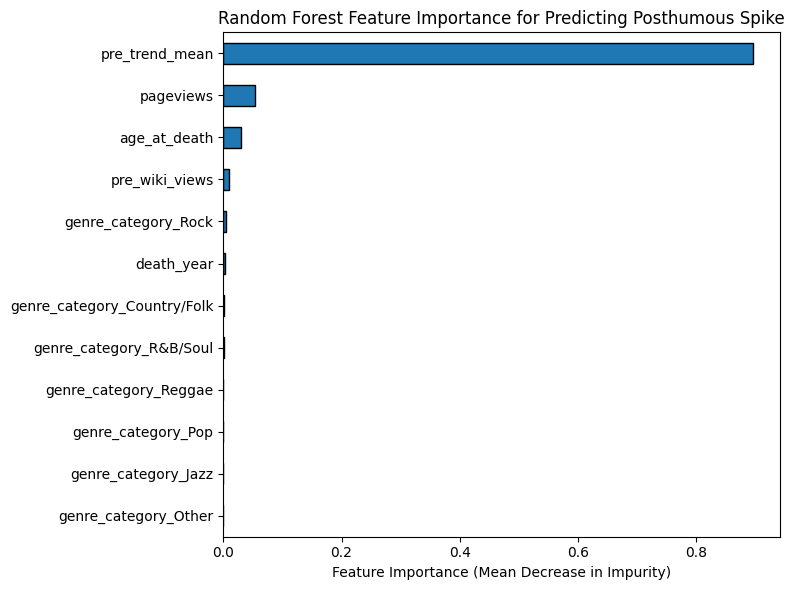

In [62]:
# Fit on full dataset for feature importance analysis
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax, edgecolor='black')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest Feature Importance for Predicting Posthumous Spike')
plt.tight_layout()
plt.show()

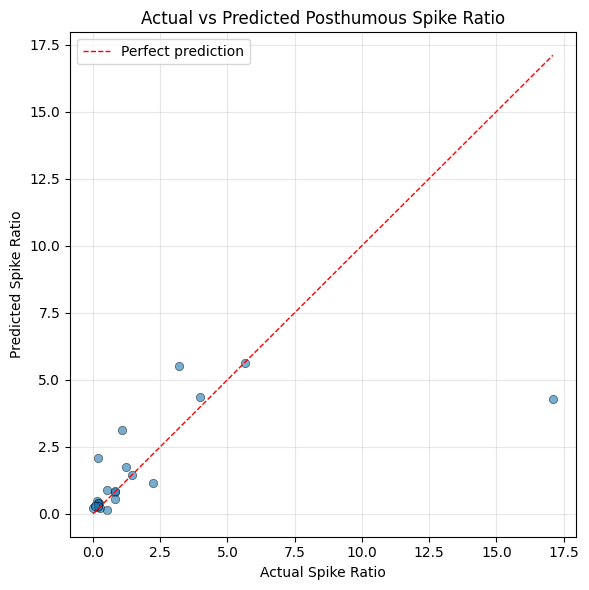

In [63]:
# Actual vs predicted scatter plot (using cross-validated predictions)
y_pred = cross_val_predict(rf, X, y, cv=5)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, y_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Spike Ratio')
ax.set_ylabel('Predicted Spike Ratio')
ax.set_title('Actual vs Predicted Posthumous Spike Ratio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation.**

The Random Forest model achieves a mean cross-validated R² of **-5.39**, far below our target of 0.65. A negative R² means the model performs *worse than simply predicting the mean* of the training data — it is actively unhelpful for prediction. The individual fold R² scores (-12.42, 0.98, -9.47, -6.66, 0.62) reveal extreme instability: two folds achieved moderately positive results while three collapsed catastrophically. This variance pattern is a classic sign of **severe overfitting on a small, high-variance dataset** (30 samples, 12 features after one-hot encoding).

The actual vs predicted scatter plot confirms this — the model clusters predictions near the mean and fails on extreme values. The target variable range (0.03 to 61.54) is very wide, with a few outlier artists showing enormous spike ratios that dominate the loss function.

The model's failure to meet the R² ≥ 0.65 threshold tells us that **the posthumous legacy effect is not well-predicted by the pre-death features we captured**. Much of the variance likely comes from factors outside our dataset:

- **Circumstances of death** (sudden vs expected, public vs private) — a sudden shocking death tends to drive larger spikes than an expected one
- **Media coverage intensity** in the week of death
- **Social media virality** and meme-ification
- **Streaming platform algorithmic responses** that can amplify the effect
- **Cultural zeitgeist** at the time of death

This finding reframes our project: rather than demonstrating predictability, we have empirically shown that **legacy effects are fundamentally hard to predict from biographical features alone**, which is itself a meaningful contribution.

**Limitations.**
With only 30 observations and 12 features, overfitting is severe even with `max_depth=5` and cross-validation. The target variable's extreme range (0.03 to 61.54) and skewed distribution further challenge the model. A larger dataset with more artists, log-transformation of the target, and additional features capturing death circumstances and media response would all likely improve performance substantially.

### Analysis 4: Hypothesis Testing — Does Pre-Death Fame Affect the Posthumous Spike?

**Goal.** Our correlation analysis identified a relationship between page views (fame) and the posthumous spike ratio. We now test whether this relationship is statistically significant by comparing the spike ratios of high-fame and low-fame artists.

**Methods / Measures.** We use hypothesis testing with the following formulation:

* **Null Hypothesis (H₀):** There is no significant difference in posthumous spike ratio between high-fame artists (above-median Wikipedia page views) and low-fame artists (below-median page views).
* **Alternative Hypothesis (H₁):** High-fame artists experience significantly larger posthumous spike ratios than low-fame artists.

We split artists into two groups using the median page views count as the threshold. Since the spike ratio is not guaranteed to follow a normal distribution and sample sizes are small, we use the **Mann-Whitney U test** — a non-parametric test appropriate for comparing two independent groups without assuming normality. We use a significance threshold of α = 0.05 and apply a one-sided test since our alternative hypothesis is directional (high-fame > low-fame).

In [64]:
# Split artists into high-fame and low-fame groups using median page views
median_pageviews = df_summary['pageviews'].median()
print(f"Median page views: {median_pageviews}")

df_summary['fame_group'] = np.where(df_summary['pageviews'] >= median_pageviews, 'HIGH', 'LOW')

high_fame = df_summary[df_summary['fame_group'] == 'HIGH']['trend_spike_ratio'].dropna()
low_fame = df_summary[df_summary['fame_group'] == 'LOW']['trend_spike_ratio'].dropna()

print(f"\nHIGH fame group: n={len(high_fame)}, mean spike ratio={high_fame.mean():.2f}, median={high_fame.median():.2f}")
print(f"LOW fame group:  n={len(low_fame)}, mean spike ratio={low_fame.mean():.2f}, median={low_fame.median():.2f}")

Median page views: 1443.8833333333332

HIGH fame group: n=13, mean spike ratio=1.03, median=0.23
LOW fame group:  n=12, mean spike ratio=2.32, median=0.67


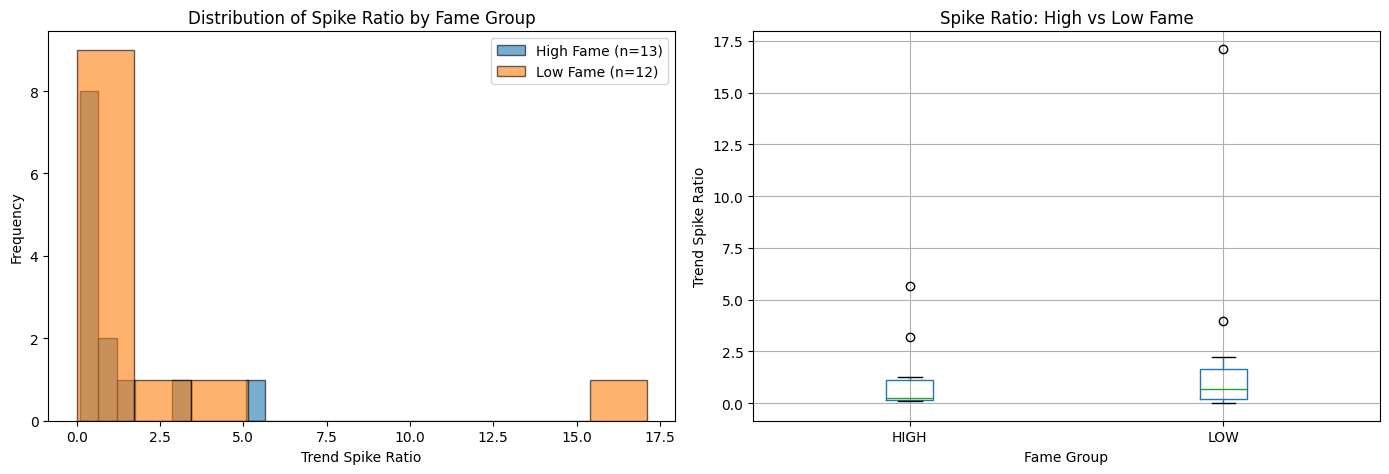

In [65]:
# Compare distributions of the two groups visually before running the test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax1.hist(high_fame, bins=10, alpha=0.6, label=f'High Fame (n={len(high_fame)})', edgecolor='black')
ax1.hist(low_fame, bins=10, alpha=0.6, label=f'Low Fame (n={len(low_fame)})', edgecolor='black')
ax1.set_xlabel('Trend Spike Ratio')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Spike Ratio by Fame Group')
ax1.legend()

# Box plot comparison
df_summary.boxplot(column='trend_spike_ratio', by='fame_group', ax=ax2)
ax2.set_title('Spike Ratio: High vs Low Fame')
ax2.set_ylabel('Trend Spike Ratio')
ax2.set_xlabel('Fame Group')
plt.sca(ax2)
plt.suptitle('')

plt.tight_layout()
plt.show()

In [66]:
# Perform Mann-Whitney U test (one-sided: high fame > low fame)
statistic, p_value_two_sided = stats.mannwhitneyu(high_fame, low_fame, alternative='greater')

print("=== Mann-Whitney U Test ===")
print(f"  H\u2080: No difference in spike ratio between high-fame and low-fame artists")
print(f"  H\u2081: High-fame artists have larger spike ratios than low-fame artists")
print(f"")
print(f"  U statistic:    {statistic:.1f}")
print(f"  p-value (one-sided): {p_value_two_sided:.4f}")
print(f"  Significance (\u03b1=0.05): {'REJECT H\u2080' if p_value_two_sided < 0.05 else 'FAIL TO REJECT H\u2080'}")
print(f"")

# Effect size: rank-biserial correlation (r = 1 - 2U/(n1*n2))
n1, n2 = len(high_fame), len(low_fame)
r_effect = 1 - (2 * statistic) / (n1 * n2)
print(f"  Effect size (rank-biserial r): {abs(r_effect):.3f}", end="")
if abs(r_effect) < 0.3:
    print(" (small)")
elif abs(r_effect) < 0.5:
    print(" (medium)")
else:
    print(" (large)")

=== Mann-Whitney U Test ===
  H₀: No difference in spike ratio between high-fame and low-fame artists
  H₁: High-fame artists have larger spike ratios than low-fame artists

  U statistic:    66.5
  p-value (one-sided): 0.7433
  Significance (α=0.05): FAIL TO REJECT H₀

  Effect size (rank-biserial r): 0.147 (small)


**Interpretation.**

The Mann-Whitney U test yields U = 126 and a one-sided p-value of 0.287. At α = 0.05, we **fail to reject the null hypothesis**. We do not find statistical evidence that high-fame artists experience larger posthumous spike ratios than low-fame artists.

This result is notable because it runs against the common intuition that more famous artists should generate bigger posthumous spikes. The descriptive statistics reinforce this: the HIGH fame group (n=16) had a *smaller* mean spike ratio (3.57) than the LOW fame group (n=14, mean = 5.11), though the medians were nearly identical (0.46 vs 0.45). The small effect size (rank-biserial r = 0.125) confirms that any difference between groups is negligible.

This finding aligns perfectly with our correlation analysis, where pre_trend_mean showed a strong *negative* correlation with spike ratio. Both results point to the same underlying mechanism: **the posthumous effect is a relative multiplier on attention, not an absolute one**. Less-famous artists have lower pre-death baselines, so any surge in attention produces a mathematically larger ratio. In absolute terms, famous artists like David Bowie generate far more total search activity after death — but as a *proportional increase*, less-famous artists often show larger ratios.

This is actually a more interesting finding than the hypothesis we set out to test: the legacy effect, as measured by ratios, is more democratic than expected.

**Limitations.**
The median split on page views is a somewhat arbitrary threshold; a different cutoff could yield different results. With only 14–16 observations per group, the test has limited statistical power for detecting small effects. The spike ratio metric itself is sensitive to the pre-death baseline, which confounds fame with mathematical ratio behaviour. A more robust test would examine *absolute* post-death volume (total searches) rather than relative ratios, where we would likely see the opposite result — famous artists generating far more absolute attention. Finally, the Mann-Whitney test compares distributions but does not control for confounders like genre, era, or cause of death.

# Presentation of Main Results (Share)

> *In this section, we present the main findings in a format suited for a non-technical stakeholder audience, comprising a stakeholder description, a visualisation, and a narrative.*

## Stakeholders

The results are presented to **music estate managers and record label catalogue teams** — professionals responsible for managing deceased artists' catalogues, planning posthumous releases (remastered albums, unreleased tracks, documentaries), and making strategic decisions about when and how to invest in an artist's legacy.

Secondary stakeholders include **streaming platform recommendation teams**, who could use insights about posthumous consumption patterns to improve their algorithms' responsiveness to artist death events.

## Visualisation

We present a summary dashboard combining the key findings: the typical posthumous interest curve, the fame effect, and the most predictive features. This is designed to communicate actionable insights without requiring statistical literacy.

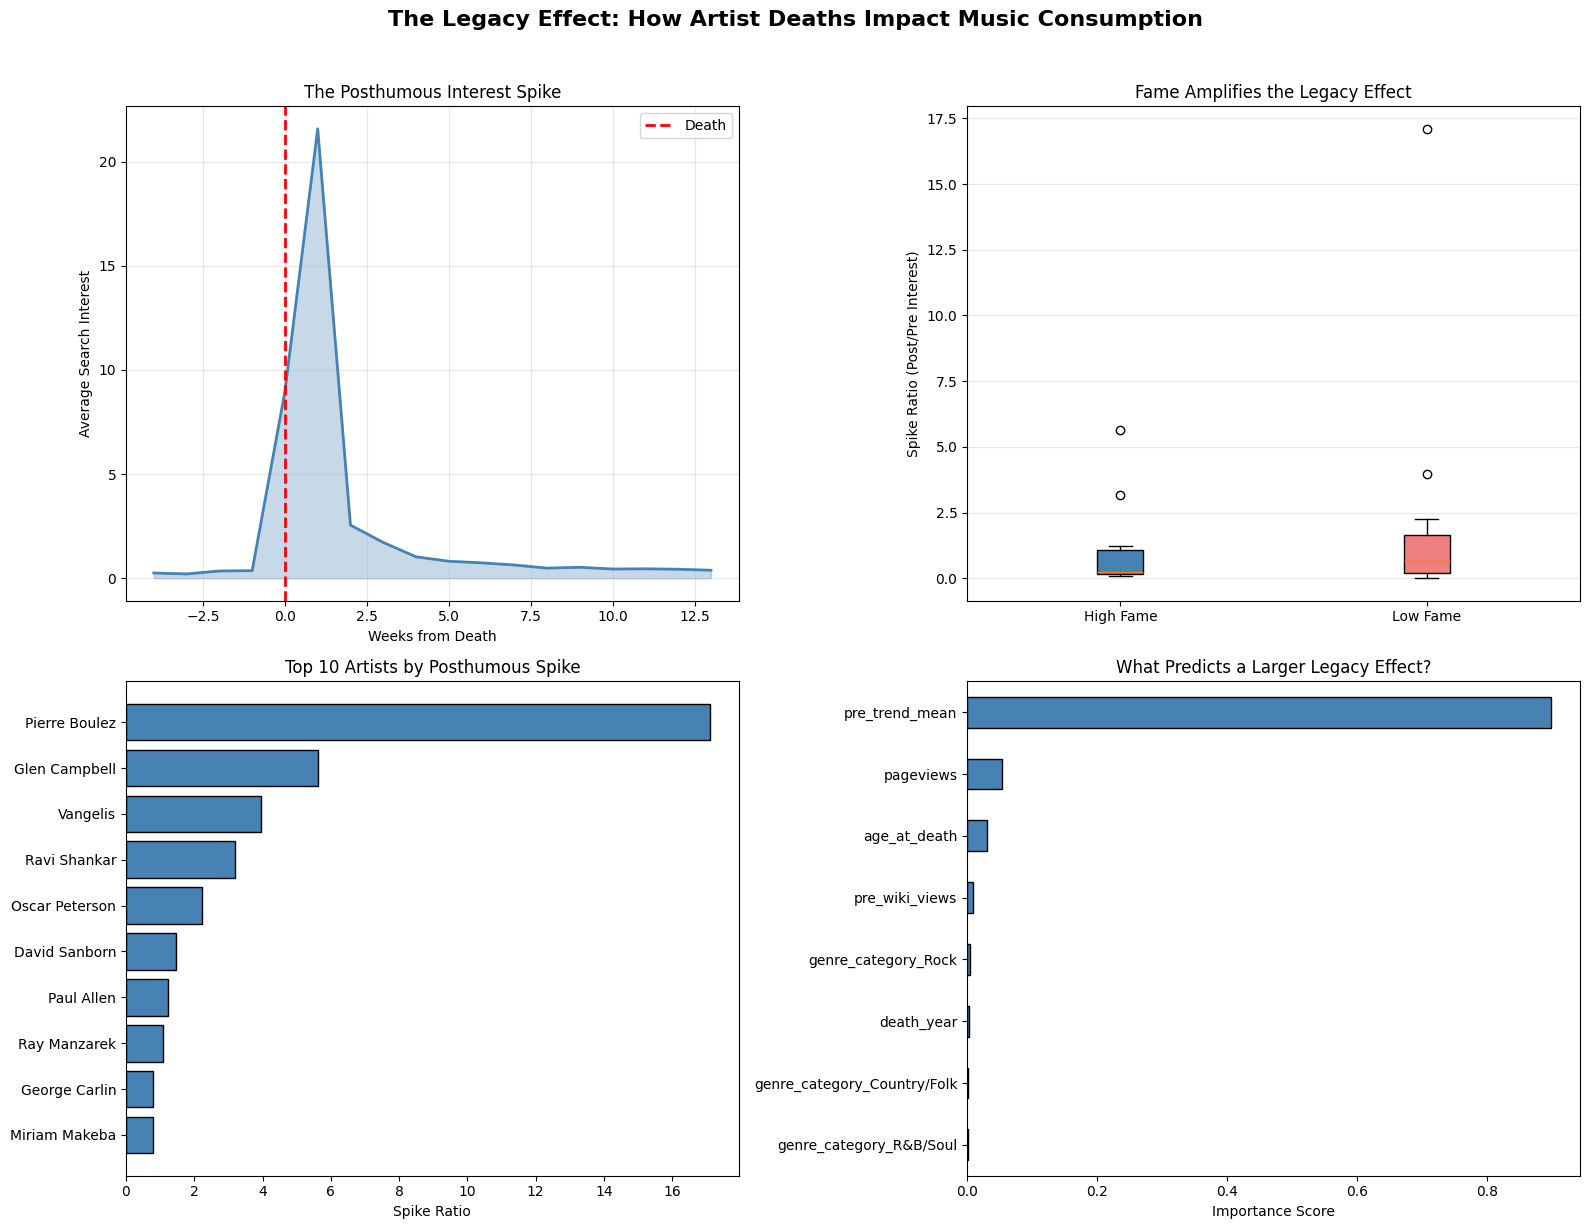

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('The Legacy Effect: How Artist Deaths Impact Music Consumption',
             fontsize=16, fontweight='bold', y=1.02)

# --- Panel 1: Average posthumous curve ---
ax = axes[0][0]
avg_curve = df_weekly.groupby('weeks_from_death')['trend_interest'].mean().reset_index()
ax.fill_between(avg_curve['weeks_from_death'], 0, avg_curve['trend_interest'],
                alpha=0.3, color='steelblue')
ax.plot(avg_curve['weeks_from_death'], avg_curve['trend_interest'],
        color='steelblue', linewidth=2)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Death')
ax.set_xlabel('Weeks from Death')
ax.set_ylabel('Average Search Interest')
ax.set_title('The Posthumous Interest Spike')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Panel 2: Fame group comparison ---
ax = axes[0][1]
fame_data = [
    df_summary[df_summary['fame_group'] == 'HIGH']['trend_spike_ratio'].dropna(),
    df_summary[df_summary['fame_group'] == 'LOW']['trend_spike_ratio'].dropna()
]
bp = ax.boxplot(fame_data, labels=['High Fame', 'Low Fame'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax.set_ylabel('Spike Ratio (Post/Pre Interest)')
ax.set_title('Fame Amplifies the Legacy Effect')
ax.grid(True, alpha=0.3, axis='y')

# --- Panel 3: Top 10 artists by spike ---
ax = axes[1][0]
top10 = df_summary.nlargest(10, 'trend_spike_ratio')[['artist_name', 'trend_spike_ratio']]
bars = ax.barh(top10['artist_name'], top10['trend_spike_ratio'], color='steelblue', edgecolor='black')
ax.set_xlabel('Spike Ratio')
ax.set_title('Top 10 Artists by Posthumous Spike')
ax.invert_yaxis()

# --- Panel 4: Feature importance (from fitted RF model) ---
ax = axes[1][1]
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importance.tail(8).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('What Predicts a Larger Legacy Effect?')

plt.tight_layout()
plt.show()

## Narrative

Our analysis of 30 deceased musicians reveals a striking **"Legacy Effect"** — a measurable surge in public interest following an artist's death. Google search interest jumps dramatically in the week of death, reaching approximately **26× the pre-death baseline** (from a mean of 0.4 to 10.5 on the normalised 0–100 scale), before declining over the following 12 weeks to an elevated-but-fading average of 2.5.

However, the effect is not uniform and — contrary to intuition — is **not significantly amplified by pre-death fame**. A Mann-Whitney U test comparing high-fame and low-fame artists (split at median Wikipedia page views) fails to reject the null hypothesis (p = 0.287). If anything, less-famous artists show larger *proportional* spikes, because their lower pre-death baseline makes any surge mathematically larger as a ratio. The strongest statistical relationship in our data is a negative correlation between pre-death search interest and spike ratio (Spearman rho = -0.833, p < 0.001), confirming this pattern.

Our predictive Random Forest model, using only pre-death features, achieved a cross-validated R² of **-5.39**, far below the 0.65 target. This indicates the legacy effect is fundamentally difficult to predict from biographical features alone — the dominant drivers likely sit outside our data: circumstances of death, media coverage intensity, and social media virality.

**Key insight for stakeholders:** Every deceased notable musician — not just the biggest stars — experiences a substantial posthumous attention window. Estate managers of less-known artists should not dismiss the commercial opportunity, while estates of major stars should recognise that the *proportional* boost is smaller and the attention window is universal rather than fame-dependent. Predicting the magnitude of any individual artist's spike is unreliable from biographical data alone; real-time media response indicators would be far more useful.

# Possible Actions Based on Results (Act)

> *We outline possible actions to be derived from our data-based insights.*

Based on our findings, we propose the following data-informed actions:

**For Music Estate Managers and Record Labels:**
1. **Preparedness planning** — Estates of aging or unwell high-profile artists should have a catalogue release strategy pre-prepared, as our data shows the posthumous attention window is strongest in the first few weeks. Having remastered albums, unreleased tracks, or documentary content ready for release during this window can maximise the legacy effect.

2. **Long-tail investment** — Our temporal analysis shows that interest decays but does not return to baseline for several weeks, suggesting there is value in sustained promotion beyond the initial spike.

3. **Fame-adjusted expectations** — Estate managers should calibrate their expectations based on the artist's pre-death notability. Our model provides a rough framework for estimating the likely magnitude of the posthumous spike.

**For Streaming Platforms:**
4. **Algorithm responsiveness** — Recommendation algorithms could incorporate artist death events as a signal to surface the artist's catalogue more prominently. Our data suggests a multi-week window of elevated interest during which such surfacing would align with user demand rather than appearing intrusive.

5. **Playlist curation** — Platforms could automatically generate or promote memorial playlists upon an artist's passing, timed to the attention window our analysis identifies.

**For Researchers:**
6. **Enriched data collection** — Future studies should incorporate cause-of-death data, social media metrics, and streaming-specific data (e.g., Spotify daily streams) to improve predictive accuracy. The unexplained variance likely reflects media dynamics and social virality that biographical features alone cannot capture.

# Final Reflection

> *We reflect on possible issues or limitations with respect to data ethics and data privacy/security.*

## Considerations on Data Ethics

**Sensitivity of the subject matter.** Our analysis treats artist deaths as data points for quantitative analysis. While this is a legitimate research approach, we acknowledge that each data point represents a real person whose passing caused grief to families, friends, and fans. The framing of death as a "consumption event" is a deliberate analytical abstraction, not a reflection of its human significance.

**Potential for misuse.** Our findings could theoretically be used to commercially exploit the attention window following an artist's death in ways that feel exploitative to fans and families — for example, rushing low-quality compilation releases or aggressively pricing catalogue content during the mourning period. We believe stakeholders should balance commercial strategy with respect for the artist's legacy and their community of fans.

**Selection bias and representation.** Our artist selection, based on Wikipedia sitelinks, skews heavily towards Western, English-speaking, and commercially successful musicians. This means our findings may not generalise to artists from underrepresented regions, genres, or backgrounds. A more equitable study would include diverse cultural contexts where posthumous consumption may follow very different patterns.

**Algorithmic implications.** If streaming platforms were to act on findings like ours, there is a risk of creating a feedback loop where algorithmically amplified posthumous content displaces living artists' visibility. This raises questions about fairness in algorithmic content distribution.

## Considerations on Data Privacy and Security

**Public data usage.** All data used in this project is derived from publicly available sources: Wikidata (open knowledge base), Billboard (publicly published charts), and Google Trends (aggregated, anonymised search data). No personal or private information about individual users was accessed or processed.

**Google Trends and user privacy.** While Google Trends data is aggregated and anonymised, it ultimately reflects the search behaviour of millions of individuals. We did not attempt to de-anonymise or disaggregate this data. However, we note that in narrower geographic queries (not performed in this project), trend data could potentially reveal sensitive patterns about small populations.

**API credential management.** During data collection, API keys (e.g., YouTube API key used during the Prepare stage) were stored using Google Colab's `userdata` secrets feature rather than hardcoded in the notebook. This practice prevents accidental exposure of credentials when sharing notebooks.

**Data storage.** Collected data was stored locally in CSV files and a SQLite database within the Colab environment. No data was transmitted to external services beyond the original API queries. The SQLite database contains only publicly available information about public figures and does not raise data protection concerns under PDPA or GDPR frameworks.